In [4]:
pip install geopandas

In [5]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 22.8 MB/s eta 0:00:00


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import rasterio
import shap
import os
from rasterio.warp import reproject, Resampling

from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.utils import resample
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_regression # Usamos datos de regresión para el ejemplo
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [5]:
PATH = "/content/drive/MyDrive/PRUEBA_CIP"

In [ ]:
gdf_04_Sectors_Tambokarkas5 = gpd.read_file(f"{PATH}/04_Sectors/Tambokarkas5.shp")
gdf_05_Soil = gpd.read_file(f"{PATH}/05_Soil Sampling Locations/Puntos_muestreo.shp")

In [ ]:
# Reproyectar el shap de sectores a UTM 19S (igual que gdf_05_Soil)
gdf_04_Sectors_Tambokarkas5 = gdf_04_Sectors_Tambokarkas5.to_crs(gdf_05_Soil.crs)

# Verificamos
print(gdf_04_Sectors_Tambokarkas5.crs)

EPSG:32719


In [ ]:
# Filtrar puntos dentro del polígono
gdf_inside = gdf_05_Soil[~gdf_05_Soil.within(gdf_04_Sectors_Tambokarkas5.geometry.iloc[0])]
gdf_inside_1 = gdf_inside['Name'].to_list()

In [ ]:
# gdf_Data_Tambokarkas = gpd.read_file(f"/content/drive/MyDrive/DATATHON CIP 2025/GEO/DATOS_FINALES/Tambokarkas/Copia de Data_Tambokarkas.shp")
gdf_Data_Tambokarkas = pd.read_csv(f"/content/drive/MyDrive/DATATHON CIP 2025/GEO/DATOS_FINALES/Tambokarkas/5meters/Tambo_5m.csv")
gdf_Data_Tambokarkas_1 = pd.read_csv(f"/content/drive/MyDrive/DATATHON CIP 2025/GEO/Data_Final_Tambo/Data_TamboKarkas.csv")

In [ ]:
gdf_Data_Tambokarkas_final = gdf_Data_Tambokarkas_1[['Name','mean_Temperatura_Minima_UTM_Corregida',
       'mean_Temperatura_Maxima_UTM_Corregida']].merge(gdf_Data_Tambokarkas, on='Name', how='left')
gdf_Data_Tambokarkas_final

In [ ]:
gdf_Data_Tambokarkas = gdf_Data_Tambokarkas_final.copy()

In [ ]:
pd.read_csv("/content/drive/MyDrive/DATATHON CIP 2025/GEO/DATOS_FINALES/Tambokarkas/Resultado_2.csv").columns

Index(['Name', 'altitudeMo', 'tessellate', 'extrude', 'visibility',
       'drawOrder', 'Numeration', 'Cover type', 'Sector', 'Elevation_',
       'UTM_Eastin', 'UTM_Northi', 'BD_10_cm', 'BD_20_cm', 'BD _30_cm',
       'Cover_type', 'Elevatio_1', 'Sand_%', 'Silt_%', 'Clay_%', 'Texture_cl',
       'C_%', 'Soil_Densi', 'Bulk_Densi', 'Carbon_Sto', 'media_raster1',
       'media_dem', 'media_eva'],
      dtype='object')

In [ ]:
pd_var_adionales = pd.read_csv("/content/drive/MyDrive/DATATHON CIP 2025/GEO/DATOS_FINALES/Tambokarkas/Resultado_2.csv")
pd_var_adionales_1 = gdf_Data_Tambokarkas.merge(pd_var_adionales[['Name','media_raster1','media_dem','media_eva']], on = 'Name', how = 'left')
pd_var_adionales_1

In [ ]:
pd_var_adionales_1 = pd_var_adionales_1[~pd_var_adionales_1['Name'].isin(gdf_inside_1)].reset_index(drop=True)
pd_var_adionales_1

In [ ]:
gdf_Data_Tambokarkas = pd_var_adionales_1.copy()

In [ ]:
gdf_Data_Tambokarkas[gdf_Data_Tambokarkas['Sand_%'] == 'Organic Matter']['Sand_%'] = "0"

/tmp/ipython-input-2090872791.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_Data_Tambokarkas[gdf_Data_Tambokarkas['Sand_%'] == 'Organic Matter']['Sand_%'] = "0"


In [ ]:
gdf_Data_Tambokarkas['Sand_%'].replace('Organic Matter', '0', inplace=True)
gdf_Data_Tambokarkas['Silt_%'].replace('Organic Matter', '0', inplace=True)
gdf_Data_Tambokarkas['Clay_%'].replace('Organic Matter', '0', inplace=True)


gdf_Data_Tambokarkas = gdf_Data_Tambokarkas[['Carbon_Sto','C_%','NDVI_1m','SAVI_1m', 'CIgreen_1m', 'NDWI_1m', 'GNDVI_1m', 'OSAVI_1m', 'NDGI_1m',
       'NDPI_1m', 'NDSVI_1m', 'TNDVI_1m','media_raster1', 'media_dem','Sand_%', 'Silt_%', 'Clay_%','media_eva','mean_Temperatura_Minima_UTM_Corregida',
       'mean_Temperatura_Maxima_UTM_Corregida']]

gdf_Data_Tambokarkas['Carbon_Sto'] = gdf_Data_Tambokarkas['Carbon_Sto'].astype(float)
gdf_Data_Tambokarkas['C_%'] = gdf_Data_Tambokarkas['C_%'].astype(float)
gdf_Data_Tambokarkas['Sand_%'] = gdf_Data_Tambokarkas['Sand_%'].astype(float)
gdf_Data_Tambokarkas['Silt_%'] = gdf_Data_Tambokarkas['Silt_%'].astype(float)
gdf_Data_Tambokarkas['Clay_%'] = gdf_Data_Tambokarkas['Clay_%'].astype(float)


/tmp/ipython-input-2172188721.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf_Data_Tambokarkas['Sand_%'].replace('Organic Matter', '0', inplace=True)
/tmp/ipython-input-2172188721.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

In [ ]:
gdf_Data_Tambokarkas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Carbon_Sto                             76 non-null     float64
 1   C_%                                    76 non-null     float64
 2   NDVI_1m                                76 non-null     float64
 3   SAVI_1m                                76 non-null     float64
 4   CIgreen_1m                             76 non-null     float64
 5   NDWI_1m                                76 non-null     float64
 6   GNDVI_1m                               76 non-null     float64
 7   OSAVI_1m                               76 non-null     float64
 8   NDGI_1m                                76 non-null     float64
 9   NDPI_1m                                76 non-null     float64
 10  NDSVI_1m                               76 non-null     float64
 11  TNDVI_1m

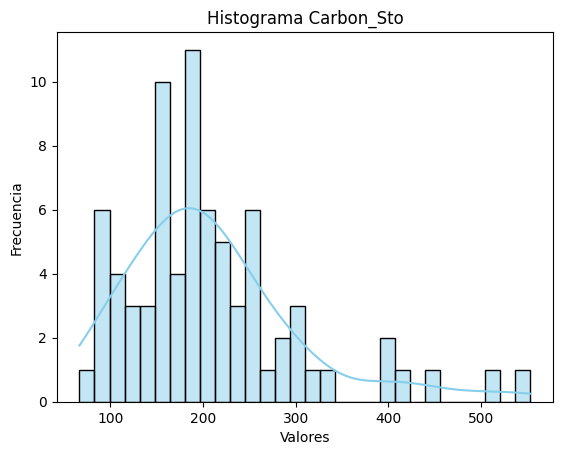

In [ ]:
sns.histplot(gdf_Data_Tambokarkas['Carbon_Sto'], bins=30, kde=True, color='skyblue')

# Personalización
plt.title('Histograma Carbon_Sto')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.show()

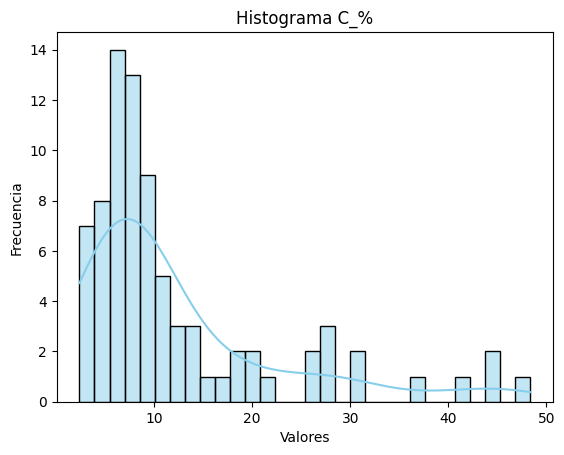

In [ ]:
sns.histplot(gdf_Data_Tambokarkas['C_%'], bins=30, kde=True, color='skyblue')

# Personalización
plt.title('Histograma C_%')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
gdf_Data_Tambokarkas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Carbon_Sto                             76 non-null     float64
 1   C_%                                    76 non-null     float64
 2   NDVI_1m                                76 non-null     float64
 3   SAVI_1m                                76 non-null     float64
 4   CIgreen_1m                             76 non-null     float64
 5   NDWI_1m                                76 non-null     float64
 6   GNDVI_1m                               76 non-null     float64
 7   OSAVI_1m                               76 non-null     float64
 8   NDGI_1m                                76 non-null     float64
 9   NDPI_1m                                76 non-null     float64
 10  NDSVI_1m                               76 non-null     float64
 11  TNDVI_1m

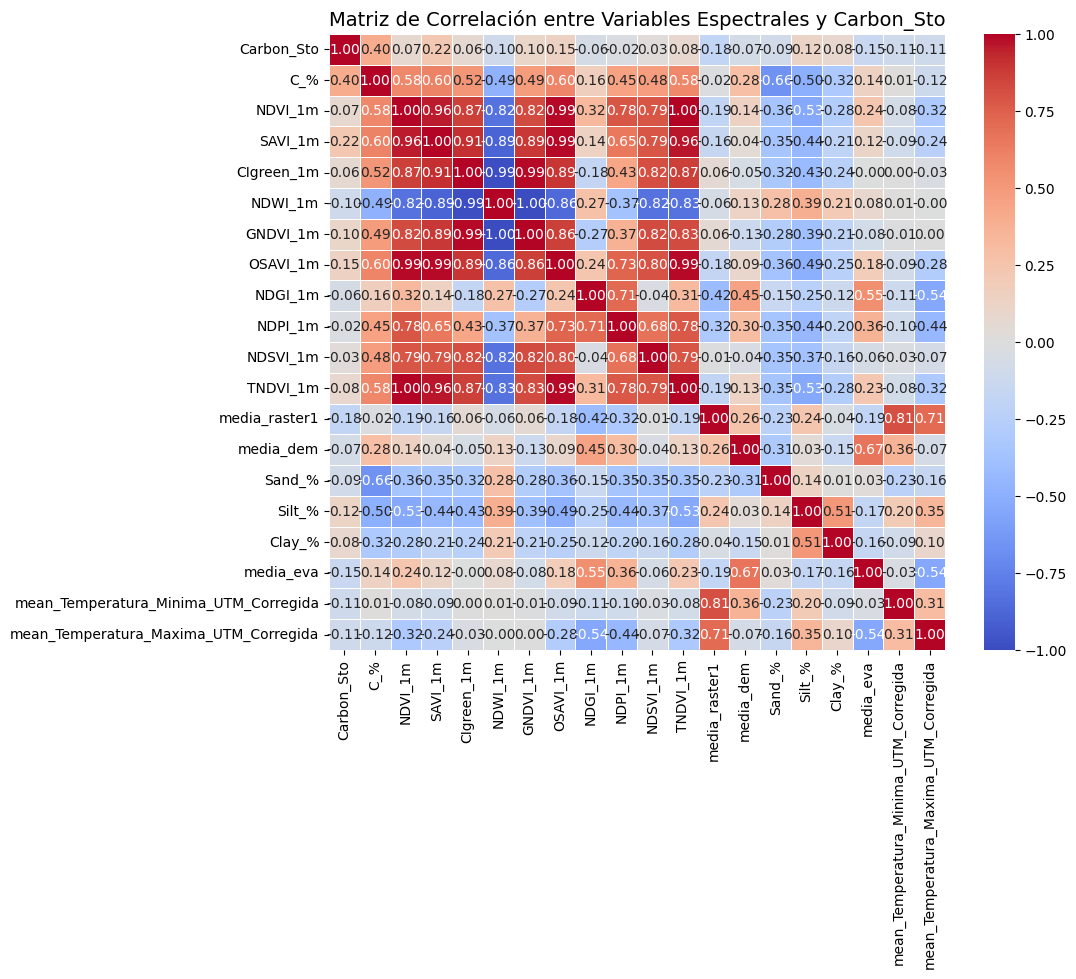

In [ ]:
corr = gdf_Data_Tambokarkas.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
)
plt.title("Matriz de Correlación entre Variables Espectrales y Carbon_Sto", fontsize=14)
plt.show()

--- Análisis de Componentes Principales ---
Componente Principal 1:
  - Varianza Explicada Individual: 0.7221 (72.21%)
  - Varianza Explicada Acumulada: 0.7221 (72.21%)
------------------------------
Componente Principal 2:
  - Varianza Explicada Individual: 0.2336 (23.36%)
  - Varianza Explicada Acumulada: 0.9557 (95.57%)
------------------------------
Componente Principal 3:
  - Varianza Explicada Individual: 0.0410 (4.10%)
  - Varianza Explicada Acumulada: 0.9967 (99.67%)
------------------------------
Componente Principal 4:
  - Varianza Explicada Individual: 0.0023 (0.23%)
  - Varianza Explicada Acumulada: 0.9990 (99.90%)
------------------------------
Componente Principal 5:
  - Varianza Explicada Individual: 0.0009 (0.09%)
  - Varianza Explicada Acumulada: 0.9999 (99.99%)
------------------------------
Componente Principal 6:
  - Varianza Explicada Individual: 0.0001 (0.01%)
  - Varianza Explicada Acumulada: 1.0000 (100.00%)
------------------------------
Componente Principal 7:

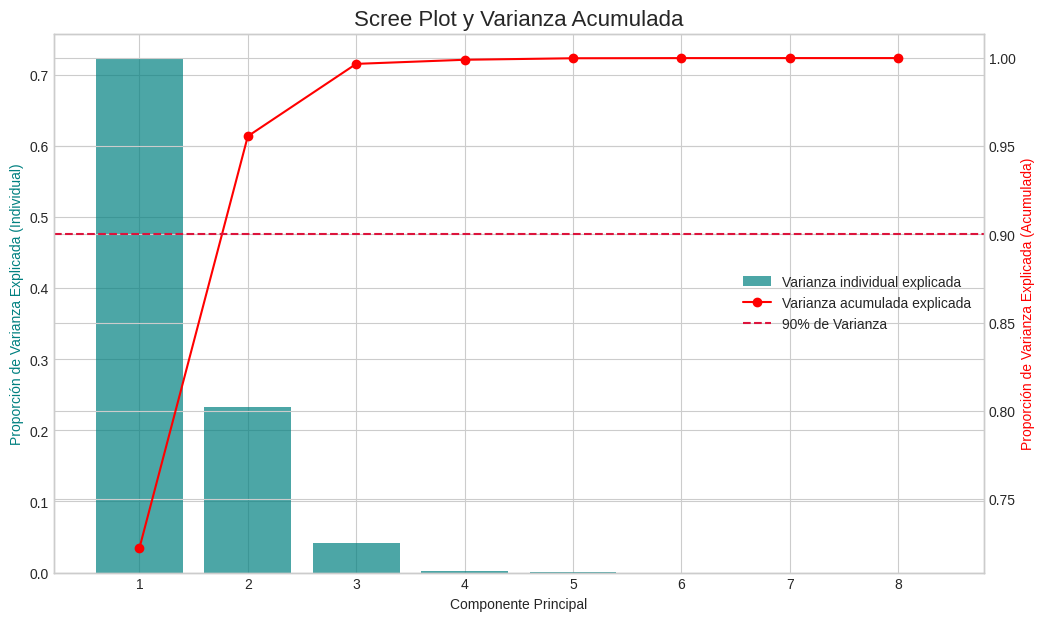

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

gdf_Data_Tambokarkas_1 = gdf_Data_Tambokarkas[[
        'NDVI_1m', 'CIgreen_1m', 'NDWI_1m', 'GNDVI_1m',
       'OSAVI_1m', 'NDGI_1m', 'NDPI_1m', 'NDSVI_1m','media_eva','mean_Temperatura_Minima_UTM_Corregida',
       'mean_Temperatura_Maxima_UTM_Corregida']]

# --- 2. Preparación de los datos ---
# Seleccionamos las columnas que nos interesan
data_para_pca = gdf_Data_Tambokarkas_1[['NDVI_1m', 'CIgreen_1m', 'NDWI_1m', 'GNDVI_1m',
       'OSAVI_1m', 'NDGI_1m', 'NDPI_1m', 'NDSVI_1m']]

# Manejamos posibles valores nulos (muy importante)
data_para_pca = data_para_pca.dropna()

# --- 3. Escalar los datos ---
# Este paso es fundamental para un PCA correcto
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_para_pca)

# --- 4. Aplicar PCA ---
# No definimos n_components todavía para calcularlos todos y analizarlos
pca = PCA()
principal_components = pca.fit_transform(data_scaled)

# --- 5. Analizar la Varianza Explicada (LA PARTE MÁS IMPORTANTE) ---

# Varianza explicada por cada componente individual
varianza_explicada = pca.explained_variance_ratio_

# Varianza explicada acumulada
varianza_acumulada = np.cumsum(varianza_explicada)

print("--- Análisis de Componentes Principales ---")
for i, (var_expl, var_acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"Componente Principal {i+1}:")
    print(f"  - Varianza Explicada Individual: {var_expl:.4f} ({var_expl*100:.2f}%)")
    print(f"  - Varianza Explicada Acumulada: {var_acum:.4f} ({var_acum*100:.2f}%)")
    print("-" * 30)

# --- 6. Visualización para la toma de decisión ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Gráfico de barras para la varianza individual (Scree Plot)
ax.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.7, align='center',
       label='Varianza individual explicada', color='teal')

# Gráfico de líneas para la varianza acumulada
ax2 = ax.twinx()
ax2.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
         'r-o', label='Varianza acumulada explicada')

# Añadir una línea de umbral (ej. 90% o 95% de la varianza)
ax2.axhline(y=0.90, color='crimson', linestyle='--', label='90% de Varianza')

# Formato del gráfico
ax.set_ylabel('Proporción de Varianza Explicada (Individual)', color='teal')
ax2.set_ylabel('Proporción de Varianza Explicada (Acumulada)', color='red')
ax.set_xlabel('Componente Principal')
ax.set_title('Scree Plot y Varianza Acumulada', fontsize=16)
ax.set_xticks(range(1, len(varianza_explicada) + 1))

# Leyendas
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right')

plt.show()

In [ ]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
gdf_Data_Tambokarkas['pc1'] = principal_df['PC1']
gdf_Data_Tambokarkas['pc2'] = principal_df['PC2']

# IMPORTACIÓN DATA

In [6]:
PATH = "/content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS"

In [7]:
gdf_Data_Tambokarkas_1 = pd.read_csv(f"{PATH}/Data_Final_Tambo/Data_TamboKarkas (1).csv")
gdf_Data_Tambokarkas_1 = gdf_Data_Tambokarkas_1[gdf_Data_Tambokarkas_1.columns[-12:]]
gdf_Data_Tambokarkas_1.columns

Index(['Carbon_Sto', 'mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration'],
      dtype='object')

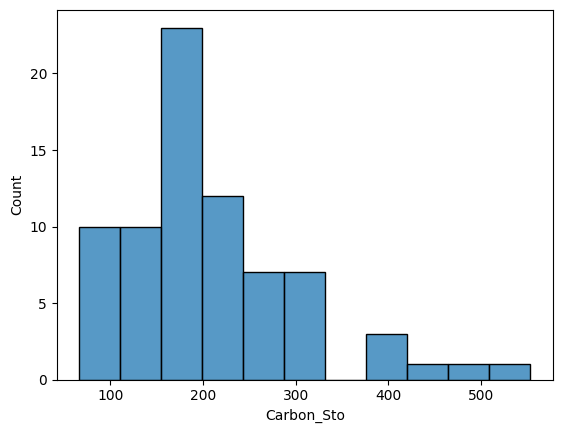

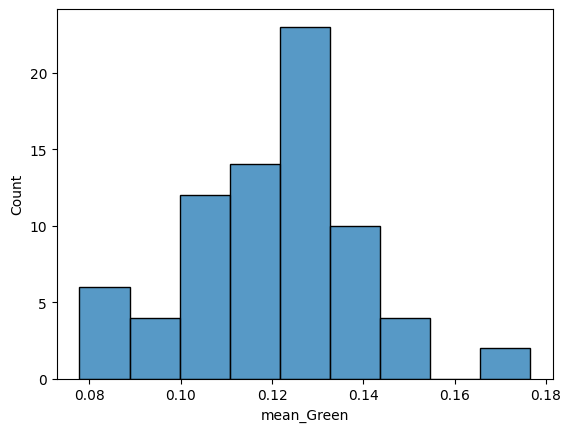

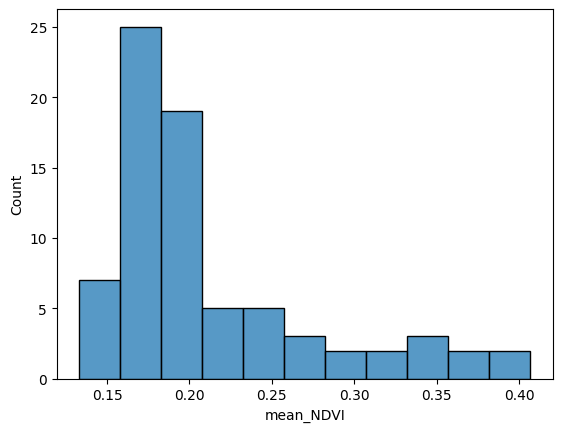

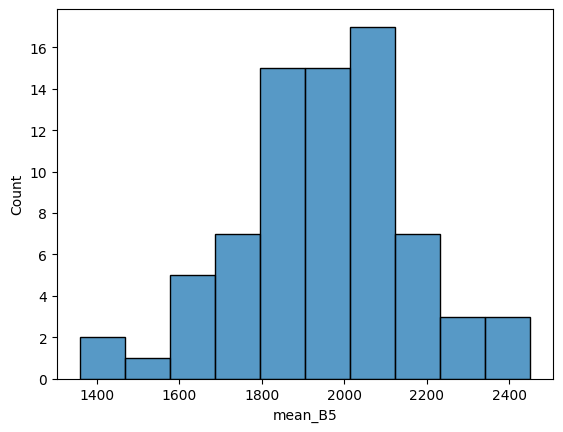

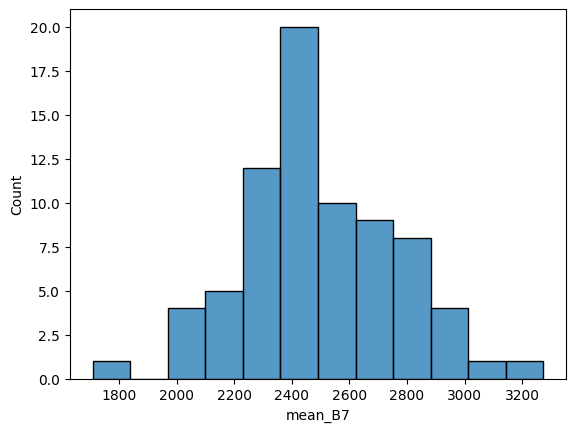

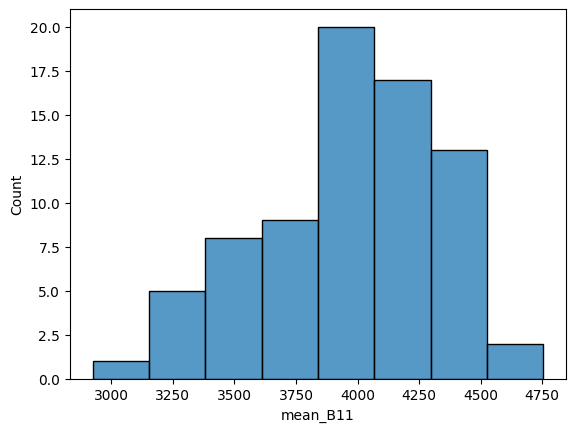

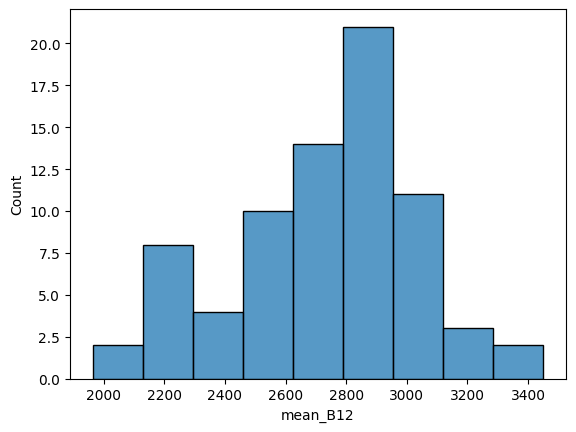

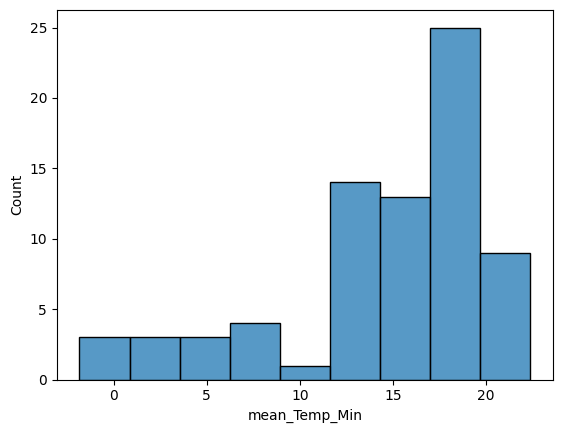

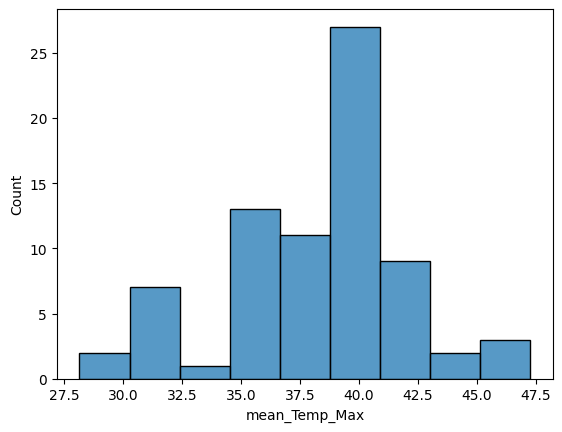

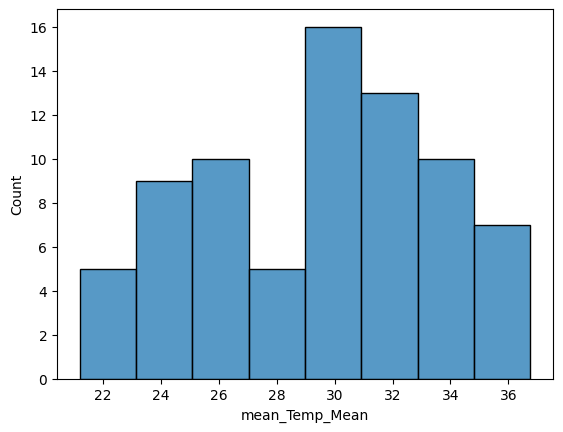

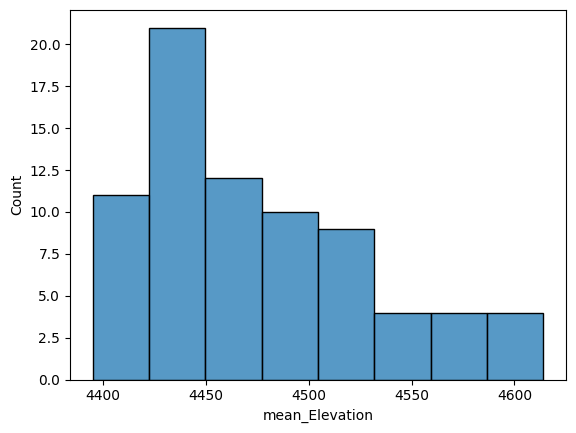

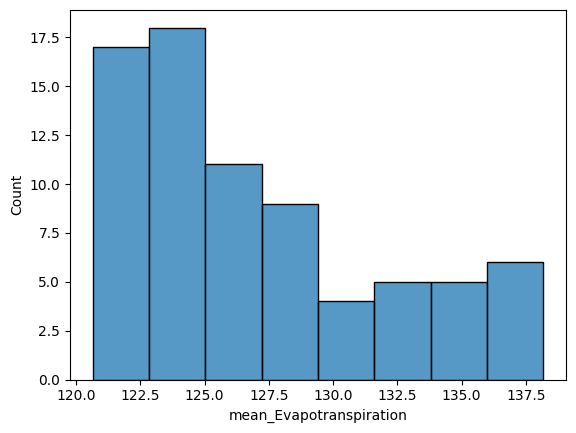

In [9]:
var = ['Carbon_Sto', 'mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration']
for i in var:
  sns.histplot(gdf_Data_Tambokarkas_1[i])
  plt.show()

In [10]:
'''
X = gdf_Data_Tambokarkas_1[[
        'pc1','pc2','media_eva','mean_Temperatura_Minima_UTM_Corregida',
       'mean_Temperatura_Maxima_UTM_Corregida']]
'''
X = gdf_Data_Tambokarkas_1[[
       'mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration']]

y = gdf_Data_Tambokarkas_1['Carbon_Sto']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

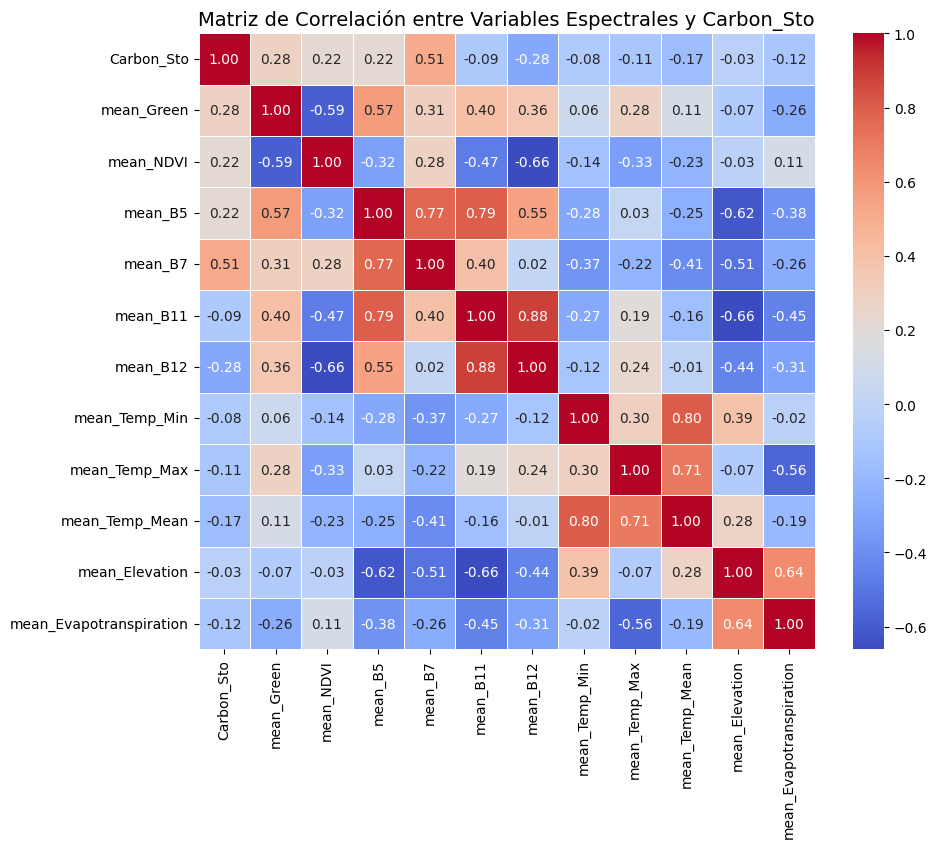

In [ ]:
corr = gdf_Data_Tambokarkas_1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
)
plt.title("Matriz de Correlación entre Variables Espectrales y Carbon_Sto", fontsize=14)
plt.show()

# **Modelos**

## SVM

In [11]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['linear', 'rbf'],
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': ['scale', 'auto', 0.1, 0.01]
}

loocv = LeaveOneOut()

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=loocv,
    # CAMBIO 3: Métrica de evaluación para regresión.
    # Usamos el error cuadrático medio negativo. Un valor más alto (cercano a 0) es mejor.
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 6. EJECUCIÓN DEL ENTRENAMIENTO
print("Iniciando la búsqueda de hiperparámetros para SVR con Leave-One-Out CV...")
grid_search.fit(X_train, y_train)
print("Búsqueda completada.")

# 7. MOSTRAR LOS MEJORES RESULTADOS
print("\n-------------------------------------------")
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
# Obtenemos el MSE y lo convertimos a positivo para que sea más fácil de interpretar.
best_mse = -grid_search.best_score_
print(f"Mejor Error Cuadrático Medio (MSE) en CV: {best_mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(best_mse):.4f}")
print("-------------------------------------------")

# El mejor modelo ya está entrenado y listo para usarse
# best_model = grid_search.best_estimator_
# predictions = best_model.predict(nuevos_datos)

Iniciando la búsqueda de hiperparámetros para SVR con Leave-One-Out CV...
Búsqueda completada.

-------------------------------------------
Mejores Hiperparámetros: {'svr__C': 100, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}
Mejor Error Cuadrático Medio (MSE) en CV: 6155.6796
Raíz del Error Cuadrático Medio (RMSE): 78.4581
-------------------------------------------


In [12]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model = grid_search.best_estimator_
predictions_train_svm = best_model.predict(X_train)
predictions_test_svm = best_model.predict(X_test)

In [13]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100


def metricas(y_train,predictions_train,y_test,predictions_test):
  print("--- Métricas en el Conjunto de Entrenamiento ---")

  mae_train = mean_absolute_error(y_train, predictions_train)
  print(f"MAE (Error Absoluto Medio) de Entrenamiento: {mae_train:.4f}")
  mse_train = mean_squared_error(y_train, predictions_train)
  rmse_train = np.sqrt(mse_train)
  print(f"RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: {rmse_train:.4f}")
  r2_train = r2_score(y_train, predictions_train)
  print(f"R² (Coeficiente de Determinación) de Entrenamiento: {r2_train:.4f}")
  mape_train = mape(y_train, predictions_train)
  print(f"MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: {mape_train:.2f}%")
  print("\n" + "="*50 + "\n")

  print("--- Métricas en el Conjunto de Prueba ---")
  mae_test = mean_absolute_error(y_test, predictions_test)
  print(f"MAE (Error Absoluto Medio) de Prueba: {mae_test:.4f}")
  mse_test = mean_squared_error(y_test, predictions_test)
  rmse_test = np.sqrt(mse_test)
  print(f"RMSE (Raíz del Error Cuadrático Medio) de Prueba: {rmse_test:.4f}")
  r2_test = r2_score(y_test, predictions_test)
  print(f"R² (Coeficiente de Determinación) de Prueba: {r2_test:.4f}")
  mape_test = mape(y_test, predictions_test)
  print(f"MAPE (Error Porcentual Absoluto Medio) de Prueba: {mape_test:.2f}%")
  print("\n" + "="*50 + "\n")
  return mae_train, rmse_train, r2_train, mape_train, mae_test, rmse_test, r2_test, mape_test

In [14]:
metricas(y_train,predictions_train_svm,y_test,predictions_test_svm)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 44.9953
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 69.5182
R² (Coeficiente de Determinación) de Entrenamiento: 0.4334
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 21.44%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 57.2740
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 92.6909
R² (Coeficiente de Determinación) de Prueba: 0.1185
MAPE (Error Porcentual Absoluto Medio) de Prueba: 25.46%




(44.99526291548182,
 np.float64(69.51815593853703),
 0.43341330762977437,
 np.float64(21.443518441202546),
 57.27404636472082,
 np.float64(92.69086115219378),
 0.11850171653453845,
 np.float64(25.458909197942344))

In [15]:
X_test_1 = pd.DataFrame(X_test, columns=X.columns)

  0%|          | 0/15 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


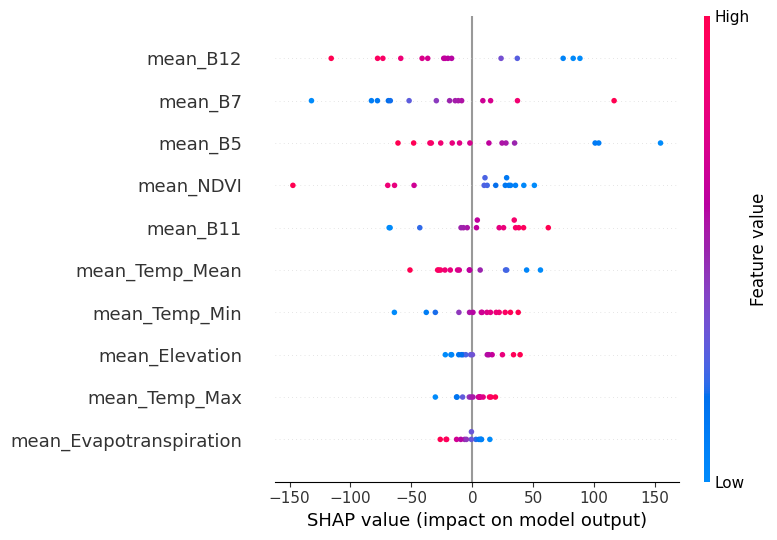


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [16]:
explainer = shap.KernelExplainer(best_model.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## Decision tree regression

In [17]:
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dtr', DecisionTreeRegressor(random_state=42))
])

# --- Hiperparámetros para evitar sobreajuste ---
# Limitamos la profundidad y exigimos más muestras para dividir o crear una hoja.
param_grid_dt = {
    'dtr__max_depth': [3, 4, 5, 6],
    'dtr__min_samples_split': [5, 10],
    'dtr__min_samples_leaf': [3, 4, 5]
}

# --- Búsqueda con LOOCV ---
loocv = LeaveOneOut()
grid_search_dt = GridSearchCV(estimator=pipe_dt,
                              param_grid=param_grid_dt,
                              cv=loocv,
                              scoring='neg_mean_squared_error',
                              n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

# --- Resultados ---
print("--- Árbol de Decisión ---")
print(f"Mejores Hiperparámetros: {grid_search_dt.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_dt.best_score_:.4f}")

--- Árbol de Decisión ---
Mejores Hiperparámetros: {'dtr__max_depth': 3, 'dtr__min_samples_leaf': 5, 'dtr__min_samples_split': 5}
Mejor MSE en CV: 3680.0681


In [18]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_dt = grid_search_dt.best_estimator_
predictions_train_dt= best_model_dt.predict(X_train)
predictions_test_dt = best_model_dt.predict(X_test)

In [19]:
metricas(y_train,predictions_train_dt,y_test,predictions_test_dt)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 30.7456
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 42.9340
R² (Coeficiente de Determinación) de Entrenamiento: 0.7839
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 15.67%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 56.8591
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 77.0491
R² (Coeficiente de Determinación) de Prueba: 0.3909
MAPE (Error Porcentual Absoluto Medio) de Prueba: 36.45%




(30.745640352407406,
 np.float64(42.93403522113951),
 0.7838907781234784,
 np.float64(15.671825133259473),
 56.859120155555566,
 np.float64(77.04906207665519),
 0.39090876535849894,
 np.float64(36.445445430948986))

  0%|          | 0/15 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


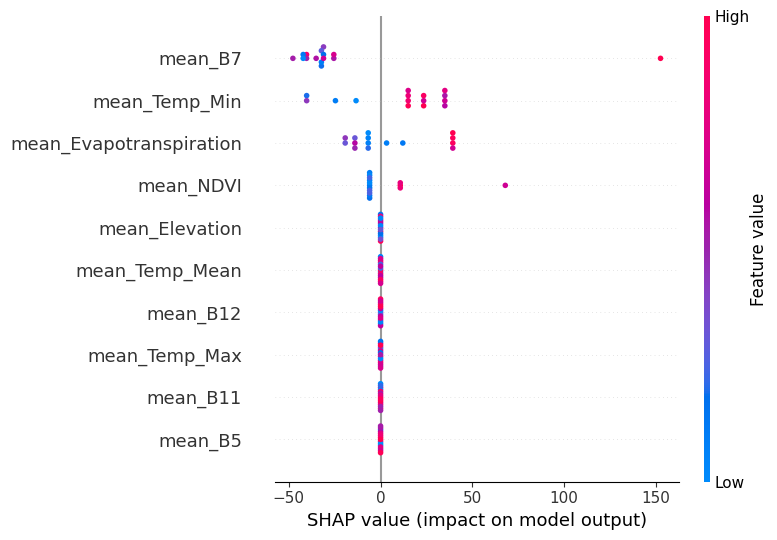


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [20]:
explainer = shap.KernelExplainer(best_model_dt.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## Random Forest



In [21]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42))
])

# --- Hiperparámetros para evitar sobreajuste ---
# Controlamos la profundidad de los árboles y el número de ellos.
param_grid_rf = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [3, 4, 5],
    'rf__min_samples_leaf': [3, 5],
    'rf__max_features': ['sqrt', 0.7]
}

# --- Búsqueda con LOOCV ---
grid_search_rf = GridSearchCV(estimator=pipe_rf, param_grid=param_grid_rf, cv=loocv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# --- Resultados ---
print("\n--- Random Forest ---")
print(f"Mejores Hiperparámetros: {grid_search_rf.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_rf.best_score_:.4f}")


--- Random Forest ---
Mejores Hiperparámetros: {'rf__max_depth': 5, 'rf__max_features': 0.7, 'rf__min_samples_leaf': 3, 'rf__n_estimators': 100}
Mejor MSE en CV: 4505.4548


In [22]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_rf = grid_search_rf.best_estimator_
predictions_train_rf= best_model_rf.predict(X_train)
predictions_test_rf = best_model_rf.predict(X_test)

In [23]:
metricas(y_train,predictions_train_rf,y_test,predictions_test_rf)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 30.1296
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 41.1143
R² (Coeficiente de Determinación) de Entrenamiento: 0.8018
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 15.62%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 54.9898
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 72.3021
R² (Coeficiente de Determinación) de Prueba: 0.4636
MAPE (Error Porcentual Absoluto Medio) de Prueba: 31.43%




(30.12957348246267,
 np.float64(41.11434547826566),
 0.8018214507277748,
 np.float64(15.619462329322314),
 54.98983559160969,
 np.float64(72.30210784896529),
 0.46364843258812627,
 np.float64(31.430575313490007))

  0%|          | 0/15 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


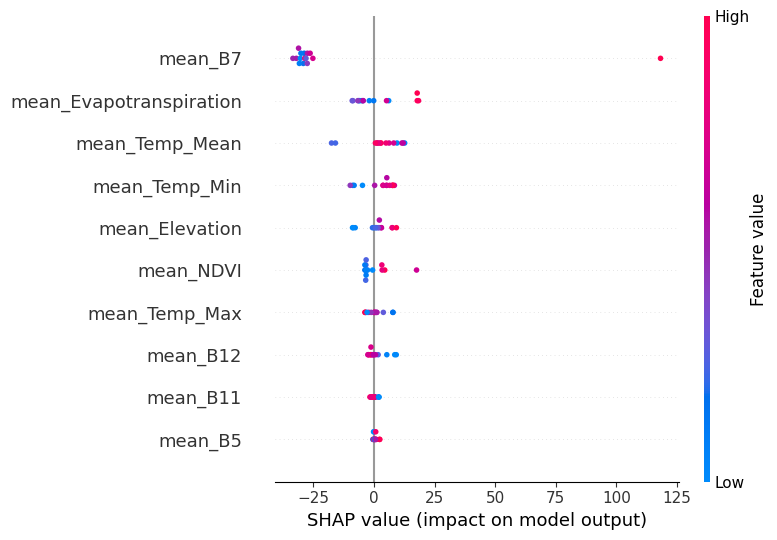


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [24]:
explainer = shap.KernelExplainer(best_model_rf.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## LASSO

In [25]:
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000)) # Aumentamos iteraciones para evitar warnings de convergencia
])

# --- Hiperparámetros para evitar sobreajuste ---
# 'alpha' es la fuerza de la regularización. Un valor más alto significa un modelo más simple.
param_grid_lasso = {
    'lasso__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
}

# --- Búsqueda con LOOCV ---
grid_search_lasso = GridSearchCV(estimator=pipe_lasso, param_grid=param_grid_lasso, cv=loocv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_train, y_train)

# --- Resultados ---
print("\n--- Lasso ---")
print(f"Mejores Hiperparámetros: {grid_search_lasso.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_lasso.best_score_:.4f}")


--- Lasso ---
Mejores Hiperparámetros: {'lasso__alpha': 0.5}
Mejor MSE en CV: 6404.1816


In [26]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_lasso = grid_search_lasso.best_estimator_
predictions_train_lasso= best_model_lasso.predict(X_train)
predictions_test_lasso = best_model_lasso.predict(X_test)

In [27]:
metricas(y_train,predictions_train_lasso,y_test,predictions_test_lasso)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 48.8859
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 63.7034
R² (Coeficiente de Determinación) de Entrenamiento: 0.5242
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 25.79%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 56.3495
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 81.5658
R² (Coeficiente de Determinación) de Prueba: 0.3174
MAPE (Error Porcentual Absoluto Medio) de Prueba: 27.84%




(48.88592636601607,
 np.float64(63.70341395433586),
 0.524231923548888,
 np.float64(25.794467203870646),
 56.34952358666639,
 np.float64(81.56583956315438),
 0.31740318358773956,
 np.float64(27.836715393369083))

  0%|          | 0/15 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


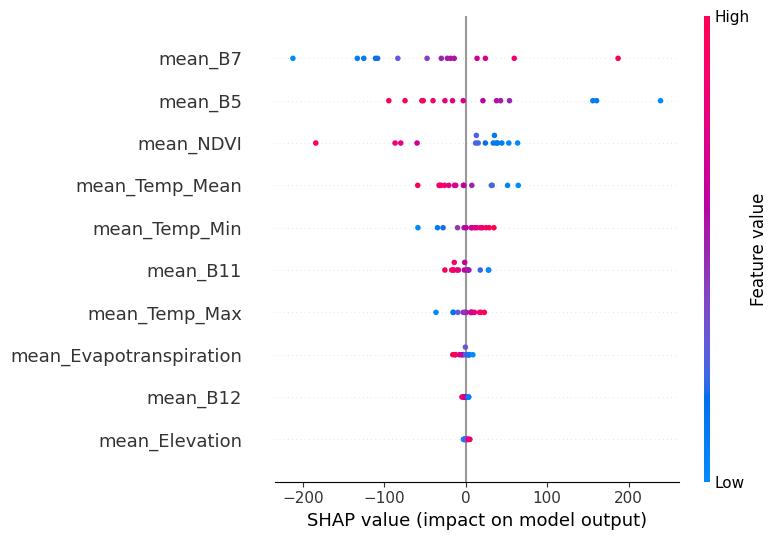


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [28]:
explainer = shap.KernelExplainer(best_model_lasso.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## Ride

In [29]:
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# --- Hiperparámetros para evitar sobreajuste ---
param_grid_ridge = {
    'ridge__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]
}

# --- Búsqueda con LOOCV ---
grid_search_ridge = GridSearchCV(estimator=pipe_ridge, param_grid=param_grid_ridge, cv=loocv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_ridge.fit(X_train, y_train)

# --- Resultados ---
print("\n--- Ridge ---")
print(f"Mejores Hiperparámetros: {grid_search_ridge.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_ridge.best_score_:.4f}")


--- Ridge ---
Mejores Hiperparámetros: {'ridge__alpha': 1.0}
Mejor MSE en CV: 6371.0955


In [30]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_ridge = grid_search_ridge.best_estimator_
predictions_train_ridge= best_model_ridge.predict(X_train)
predictions_test_ridge = best_model_ridge.predict(X_test)

In [31]:
metricas(y_train,predictions_train_ridge,y_test,predictions_test_ridge)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 49.7812
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 65.0676
R² (Coeficiente de Determinación) de Entrenamiento: 0.5036
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 26.09%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 56.3258
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 81.8473
R² (Coeficiente de Determinación) de Prueba: 0.3127
MAPE (Error Porcentual Absoluto Medio) de Prueba: 27.79%




(49.7812073291464,
 np.float64(65.0676006294249),
 0.5036369231910254,
 np.float64(26.091019039448827),
 56.32577359147589,
 np.float64(81.84728406842909),
 0.3126844295272233,
 np.float64(27.790082551148128))

  0%|          | 0/15 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


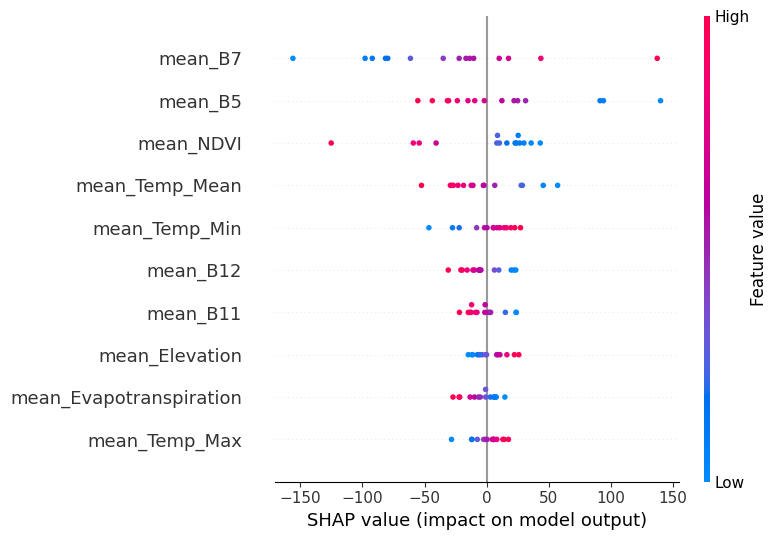


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [32]:
explainer = shap.KernelExplainer(best_model_ridge.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## XGboost


In [33]:
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

# --- Hiperparámetros para evitar sobreajuste ---
# Combinamos una tasa de aprendizaje baja con pocos estimadores, árboles poco profundos y regularización.
param_grid_xgb = {
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth': [2, 3, 4],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__subsample': [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8]
}

# --- Búsqueda con LOOCV ---
grid_search_xgb = GridSearchCV(estimator=pipe_xgb, param_grid=param_grid_xgb, cv=loocv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

# --- Resultados ---
print("\n--- XGBoost ---")
print(f"Mejores Hiperparámetros: {grid_search_xgb.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_xgb.best_score_:.4f}")


--- XGBoost ---
Mejores Hiperparámetros: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 2, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Mejor MSE en CV: 4210.3729


In [34]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_xgb = grid_search_xgb.best_estimator_
predictions_train_xgb= best_model_xgb.predict(X_train)
predictions_test_xgb = best_model_xgb.predict(X_test)

In [35]:
metricas(y_train,predictions_train_xgb,y_test,predictions_test_xgb)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 10.8327
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 13.7275
R² (Coeficiente de Determinación) de Entrenamiento: 0.9779
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 5.63%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 59.9926
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 75.7634
R² (Coeficiente de Determinación) de Prueba: 0.4111
MAPE (Error Porcentual Absoluto Medio) de Prueba: 32.06%




(10.832691142849935,
 np.float64(13.727506517274277),
 0.9779070759127826,
 np.float64(5.634296478210903),
 59.99263382999349,
 np.float64(75.76336717329237),
 0.4110666167396414,
 np.float64(32.05538447296633))

  0%|          | 0/15 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


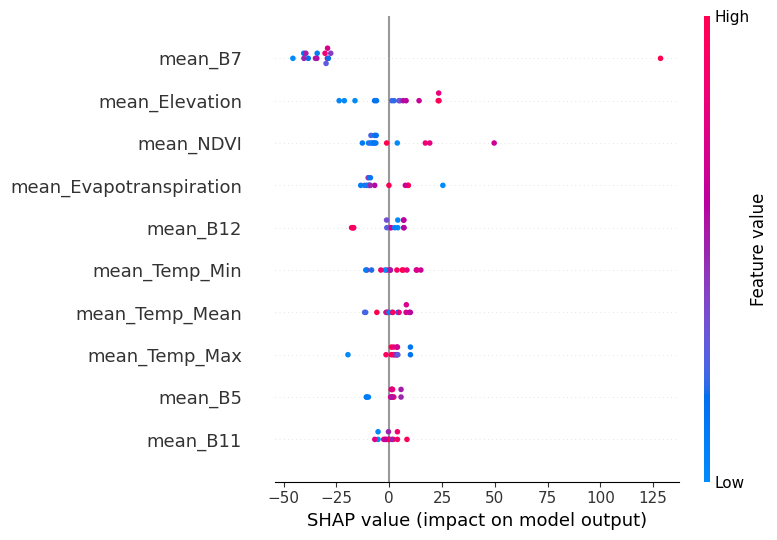


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [36]:
explainer = shap.KernelExplainer(best_model_xgb.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## Resultados

In [37]:
column_names = [
    'MAE_Train', 'RMSE_Train', 'R2_Train', 'MAPE_Train',
    'MAE_Test', 'RMSE_Test', 'R2_Test', 'MAPE_Test'
]

# 2. Define los nombres de tus modelos (las filas)
model_names = [
    'SVM',
    'Descision Tree',
    'Random Forest',
    'Lasso',
    'Ride',
    'XGBoost'
]

# 3. Recolecta los resultados de cada modelo en una lista de tuplas
#    (He simulado los resultados de otros modelos para el ejemplo)
model_results = [
   metricas(y_train,predictions_train_svm,y_test,predictions_test_svm),
   metricas(y_train,predictions_train_dt,y_test,predictions_test_dt),
   metricas(y_train,predictions_train_rf,y_test,predictions_test_rf),
   metricas(y_train,predictions_train_lasso,y_test,predictions_test_lasso),
   metricas(y_train,predictions_train_ridge,y_test,predictions_test_ridge),
   metricas(y_train,predictions_train_xgb,y_test,predictions_test_xgb)
]

# 4. Crea el DataFrame 📊
df_resultados = pd.DataFrame(data=model_results, index=model_names, columns=column_names)

# Opcional: Redondear los valores para una mejor visualización
df_resultados = df_resultados.round(4)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 44.9953
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 69.5182
R² (Coeficiente de Determinación) de Entrenamiento: 0.4334
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 21.44%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 57.2740
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 92.6909
R² (Coeficiente de Determinación) de Prueba: 0.1185
MAPE (Error Porcentual Absoluto Medio) de Prueba: 25.46%


--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 30.7456
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 42.9340
R² (Coeficiente de Determinación) de Entrenamiento: 0.7839
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 15.67%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 56.8591
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 77.0491
R² (Coeficien

In [38]:
df_resultados

,MAE_Train,RMSE_Train,R2_Train,MAPE_Train,MAE_Test,RMSE_Test,R2_Test,MAPE_Test
SVM,44.9953,69.5182,0.4334,21.4435,57.2740,92.6909,0.1185,25.4589
Descision Tree,30.7456,42.9340,0.7839,15.6718,56.8591,77.0491,0.3909,36.4454
Random Forest,30.1296,41.1143,0.8018,15.6195,54.9898,72.3021,0.4636,31.4306
Lasso,48.8859,63.7034,0.5242,25.7945,56.3495,81.5658,0.3174,27.8367
Ride,49.7812,65.0676,0.5036,26.0910,56.3258,81.8473,0.3127,27.7901
XGBoost,10.8327,13.7275,0.9779,5.6343,59.9926,75.7634,0.4111,32.0554


In [39]:
variables = ['mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration']

## Mapa

In [ ]:
# ================================================================
# 6️⃣ APLICAR MODELO A RASTER MULTIBANDA
# ================================================================
ruta_tif = f"{PATH}/Data_Final_Tambo/TamboBandas (3).tif"

with rasterio.open(ruta_tif) as src:
    img = src.read()  # (bandas, filas, columnas)
    profile = src.profile # Guarda el perfil para exportar después

print(f"\nBandas encontradas en el raster: {img.shape[0]}")

if img.shape[0] < len(variables):
    raise ValueError("El raster no contiene todas las bandas esperadas.")

# 1. PREPARAR DATOS
# ----------------------------------------------------------------
# Reorganizar a (píxeles, bandas)
n_bands, n_rows, n_cols = img.shape
pixels = img.reshape(n_bands, -1).T
X_raster = pd.DataFrame(pixels, columns=variables)

# Reemplazar infinitos por NaN
X_raster.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. SEPARAR PÍXELES VÁLIDOS Y NULOS
# ----------------------------------------------------------------
# Crear una máscara booleana: True para filas sin ningún NaN
valid_pixels_mask = ~X_raster.isnull().any(axis=1)

# Crear el DataFrame solo con los datos válidos que se procesarán
X_raster_valid = X_raster[valid_pixels_mask]


# 3. APLICAR MODELO (SOLO A DATOS VÁLIDOS)
# ----------------------------------------------------------------
# Crear un array para el resultado final, inicializado con NaN
# Usamos np.nan en lugar de -999999 como valor nulo estándar
final_prediction = np.full(X_raster.shape[0], np.nan)

# Proceder solo si hay píxeles válidos que procesar
if not X_raster_valid.empty:
    # Estandarizar únicamente los datos válidos
    X_raster_valid_scaled = scaler.transform(X_raster_valid)

    # Predecir sobre los datos estandarizados
    predictions = best_model_lasso.predict(X_raster_valid_scaled)

    # Insertar las predicciones en las posiciones correctas del array final
    final_prediction[valid_pixels_mask] = predictions


# 4. RECONSTRUIR EL RASTER DE SALIDA
# ----------------------------------------------------------------
# Reconvertir el vector de predicciones a su forma matricial (filas, columnas)
prediction_reshaped = final_prediction.reshape(n_rows, n_cols)

print("\nProceso completado.")
print(f"Forma del resultado: {prediction_reshaped.shape}")
print(f"Total de píxeles: {n_rows * n_cols}")
print(f"Píxeles procesados: {len(X_raster_valid)}")
print(f"Píxeles con NaN (ignorados): {np.isnan(prediction_reshaped).sum()}")


Bandas encontradas en el raster: 11

Proceso completado.
Forma del resultado: (330, 302)
Total de píxeles: 99660
Píxeles procesados: 48058
Píxeles con NaN (ignorados): 51602


In [ ]:
prediction_reshaped_3 = prediction_reshaped.copy()

In [ ]:
with rasterio.open(ruta_tif) as src:
    meta = src.meta
    height, width = src.height, src.width
    # ...

# ... (Aquí ocurre toda la predicción del modelo) ...

# 2. ACTUALIZA DETALLES MENORES EN LA ETIQUETA
# Cambiamos el tipo de dato a float (para las probabilidades) y el número de bandas a 1.
# ¡No tocamos el CRS ni la transformación!
meta.update(dtype='float32', count=1)

# 3. CREA EL ARCHIVO DE SALIDA USANDO LA ETIQUETA ORIGINAL
# La magia ocurre en '**meta'
# Esto le pasa toda la información geográfica guardada a tu nuevo archivo.
output_path = "/content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS/mapa_CARBONO_STOCK.tif"
with rasterio.open(output_path, 'w', **meta) as dst:
    dst.write(prediction_reshaped_3, 1)

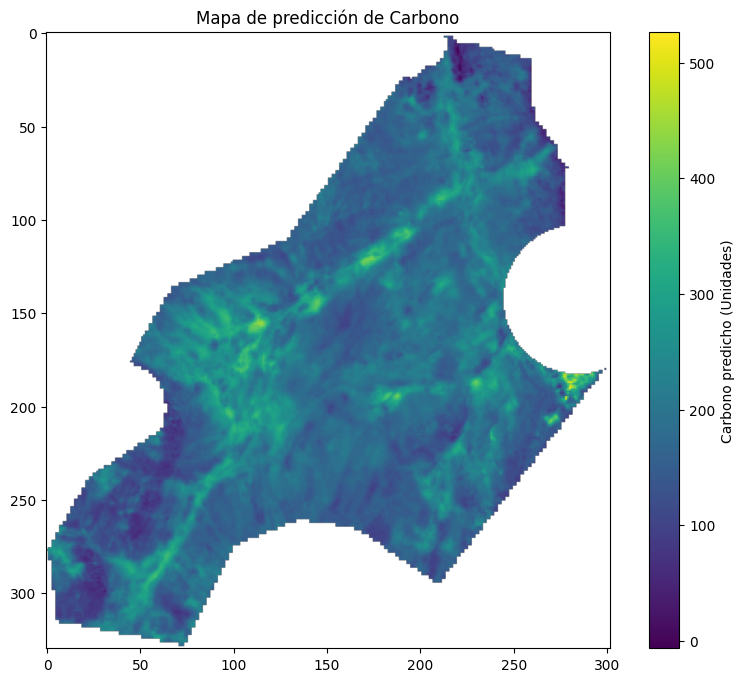

In [ ]:
plt.figure(figsize=(10, 8)) # Ajusta el tamaño para una mejor proporción
plt.imshow(prediction_reshaped, cmap='viridis')
plt.colorbar(label='Carbono predicho (Unidades)')
plt.title('Mapa de predicción de Carbono')

# Guardar la figura con alta resolución (300 DPI)
#plt.savefig('Mapa_Dry_weight_resolucion.tif', dpi=300, bbox_inches='tight')

plt.savefig('mapa_carbono_alta_resolucion.tif', dpi=300, bbox_inches='tight')

plt.show() # Puedes seguir mostrándolo si quieres

In [ ]:
import rasterio
import numpy as np
from rasterio.crs import CRS

# Asumimos que 'prediction_reshaped' es tu array de NumPy
# y que tienes un archivo 'imagen_origen.tif' del cual se basó tu predicción.

# 1. Abre el archivo de origen para leer sus metadatos
try:
    with rasterio.open('/content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS/mapa_carbono_alta_resolucion.tif') as src:
        # Copia el perfil (metadatos) del archivo de origen
        profile = src.profile

        # Obtén la transformación y el CRS originales
        transform = src.transform
        crs_original = src.crs

    # 2. Actualiza el perfil para tu nuevo archivo de salida
    # Asegúrate de que el tipo de dato (dtype) coincida con tu array de predicción
    profile.update(
        dtype=prediction_reshaped.dtype,
        count=1,  # Número de bandas (asumimos 1 para tu mapa de carbono)
        compress='lzw' # Opcional: añade compresión
    )

    # 3. Asigna el CRS deseado (EPSG:32719)
    # ¡Importante! Esto solo RE-ETIQUETA el archivo.
    # NO lo reproyecta. Si el archivo de origen NO está en 32719,
    # necesitarías reproyectarlo, lo cual es un paso más complejo.
    # Por ahora, asumimos que quieres ETIQUETARLO como 32719.
    profile['crs'] = CRS.from_epsg(32719)

    # 4. Escribe tu array 'prediction_reshaped' en un nuevo archivo GeoTIFF
    with rasterio.open('/content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS/mapa_carbono_georreferenciado.tif', 'w', **profile) as dst:
        dst.write(prediction_reshaped, 1) # Escribe en la banda 1

    print("¡GeoTIFF guardado exitosamente!")

except FileNotFoundError:
    print("Error: No se encontró el archivo 'imagen_origen.tif'.")
    print("Necesitas un archivo de origen para copiar la georreferenciación.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


¡GeoTIFF guardado exitosamente!


# New Section

In [ ]:
prediction_reshaped_1 = np.where(prediction_reshaped > 400,np.nan , prediction_reshaped)

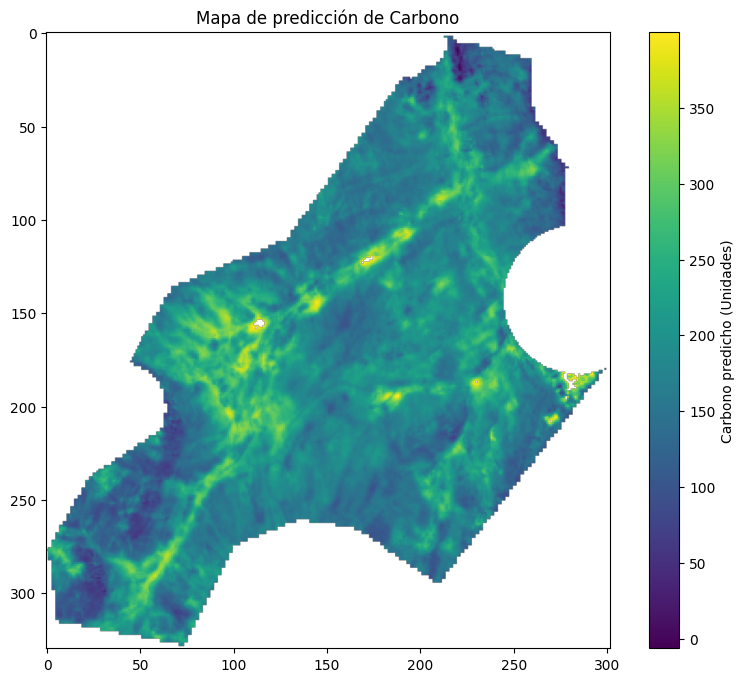

In [ ]:
plt.figure(figsize=(10, 8)) # Ajusta el tamaño para una mejor proporción
plt.imshow(prediction_reshaped_1, cmap='viridis')
plt.colorbar(label='Carbono predicho (Unidades)')
plt.title('Mapa de predicción de Carbono')

# Guardar la figura con alta resolución (300 DPI)
plt.savefig('mapa_carbono_alta_resolucion_1.png', dpi=300, bbox_inches='tight')

plt.show() # Puedes seguir mostrándolo si quieres

# Dry Weight

In [8]:
PATH = "/content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS"

In [9]:
# TRANSECTOS NO/SE/... AQUI SE EXTRAE EL DRY_WEIGHT
gdf_points_trans = gpd.read_file(f"{PATH}/Tambokarkas_TRANSECTOS/transectos/puntos_con_indices.shp")
gdf_points_trans.dropna(inplace=True)

In [10]:
gdf_04_Sectors_Tambokarkas5 = gpd.read_file(f"{PATH}/04_Sectors/Tambokarkas5.shp")
gdf_05_Soil = gpd.read_file(f"{PATH}/05_Soil Sampling Locations/Puntos_muestreo.shp")

# Reproyectar el shap de sectores a UTM 19S (igual que gdf_05_Soil)
gdf_04_Sectors_Tambokarkas5 = gdf_04_Sectors_Tambokarkas5.to_crs(gdf_05_Soil.crs)
# Verificamos
print(gdf_04_Sectors_Tambokarkas5.crs)

gdf_inside = gdf_05_Soil[~gdf_05_Soil.within(gdf_04_Sectors_Tambokarkas5.geometry.iloc[0])]
gdf_inside_1 = gdf_inside['Name'].to_list()

EPSG:32719


In [11]:
# SHAPE FINAL
gdf_points_trans = gdf_points_trans[~gdf_points_trans['Name'].isin(gdf_inside_1)].reset_index(drop=True)

In [12]:
def agregar_bandas_a_raster(ruta_raster_base, lista_rutas_nuevas, ruta_salida):
    """
    Añade nuevas bandas (desde archivos separados) a un ráster base existente.

    Toma un GeoTIFF 'base', lee todas sus bandas, y luego reproyecta
    cada archivo en 'lista_rutas_nuevas' para que coincida exactamente
    con la georreferenciación y el grid del 'base'.
    Finalmente, guarda un nuevo GeoTIFF con todas las bandas apiladas.

    Args:
        ruta_raster_base (str): Ruta al GeoTIFF que ya tiene 5-6 bandas.
                                  Este será usado como la plantilla.
        lista_rutas_nuevas (list): Una lista de strings, donde cada string es
                                   la ruta a un .tif de 1 banda que se
                                   quiere agregar.
        ruta_salida (str): Ruta donde se guardará el archivo .tif combinado.
    """

    # Lista para guardar todas las bandas como arrays de NumPy
    bandas_finales = []

    # Lista para guardar los nombres (descripciones) de las bandas
    nombres_bandas_finales = []

    try:
        # --- 1. Leer el Ráster Base ---
        print(f"Abriendo ráster base: {ruta_raster_base}")
        with rasterio.open(ruta_raster_base) as src_base:

            # Obtener los metadatos. Esta será nuestra plantilla de salida
            profile = src_base.meta.copy()

            # Leer todas las bandas existentes (ej. las 5-6)
            base_bands = src_base.read()

            # Añadir las bandas existentes a nuestra lista final
            for i in range(base_bands.shape[0]):
                bandas_finales.append(base_bands[i])

            # Guardar los nombres de las bandas existentes
            for i in range(src_base.count):
                desc = src_base.descriptions[i]
                # Usar un nombre genérico si no tiene descripción
                nombres_bandas_finales.append(desc or f'Banda_Base_{i+1}')

            print(f"Cargadas {len(bandas_finales)} bandas desde el archivo base.")

        # --- 2. Leer y Reproyectar las Nuevas Bandas ---
        for ruta_nueva in lista_rutas_nuevas:
            print(f"Procesando y alineando nueva banda: {os.path.basename(ruta_nueva)}")

            with rasterio.open(ruta_nueva) as src_nueva:
                # Crear un "lienzo" vacío con la forma exacta del ráster base
                # Usamos el dtype del profile (ej. float32)
                banda_reproyectada = np.zeros(
                    (src_base.height, src_base.width),
                    dtype=profile['dtype']
                )

                # Reproyectar la nueva banda sobre el "lienzo"
                reproject(
                    source=src_nueva.read(1),
                    destination=banda_reproyectada,
                    src_transform=src_nueva.transform,
                    src_crs=src_nueva.crs,
                    dst_transform=profile['transform'],
                    dst_crs=profile['crs'],
                    resampling=Resampling.bilinear,
                    # Definir nodata de origen para manejarlo correctamente
                    src_nodata=src_nueva.nodata,
                    # Definir nodata de destino (del profile)
                    dst_nodata=profile.get('nodata')
                )

                # Añadir la banda alineada a nuestra lista
                bandas_finales.append(banda_reproyectada)

                # Generar un nombre para la nueva banda a partir del nombre del archivo
                nombre_nuevo = os.path.splitext(os.path.basename(ruta_nueva))[0]
                nombres_bandas_finales.append(nombre_nuevo)

        # --- 3. Apilar (Stack) todas las bandas ---
        print("Apilando todas las bandas...")
        stacked_array = np.stack(bandas_finales, axis=0)

        # --- 4. Actualizar Metadatos y Guardar ---

        # Actualizar el conteo de bandas en el perfil
        profile.update(
            count=stacked_array.shape[0],
            dtype=stacked_array.dtype, # Asegurar que el dtype coincida
            compress='lzw' # Añadir compresión es buena idea
        )

        # Asegurarse de que el directorio de salida exista
        os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

        print(f"Guardando archivo final en: {ruta_salida}")
        with rasterio.open(ruta_salida, 'w', **profile) as dst:
            # Escribir todas las bandas apiladas
            dst.write(stacked_array)

            # Escribir las descripciones (nombres) de las bandas
            for i, band_name in enumerate(nombres_bandas_finales):
                dst.set_band_description(i + 1, band_name)

        print("--- ¡Proceso completado! ---")
        print(f"Total de bandas en el nuevo archivo: {stacked_array.shape[0]}")
        print("Nombres de las bandas:", nombres_bandas_finales)

    except Exception as e:
        print(f"Error: {e}")

In [13]:
# BANDAS
ruta_base = f"{PATH}/Data_Final_Tambo/TamboBandas (3).tif"
ruta_final = f"{PATH}/Data_Final_Tambo/Cobertura/Bandas_F.tif"

# 2. Una lista con las rutas de los 3 nuevos archivos que quieres añadir
lista_nuevas = [
    f"{PATH}/datos_10m_MAPA_COMPLETO/clip_CIgreen_10m_tamb.tif",
    f"{PATH}/datos_10m_MAPA_COMPLETO/clip_NDWI_10m_tamb.tif",
    f"{PATH}/datos_10m_MAPA_COMPLETO/clip_OSAVI_10m_tamb.tif",
    f"{PATH}/datos_10m_MAPA_COMPLETO/clip_TNDVI_10m_tamb.tif"
]

# 4. Ejecutar la función
agregar_bandas_a_raster(ruta_base, lista_nuevas, ruta_final)

Abriendo ráster base: /content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS/Data_Final_Tambo/TamboBandas (3).tif
Cargadas 11 bandas desde el archivo base.
Procesando y alineando nueva banda: clip_CIgreen_10m_tamb.tif
Procesando y alineando nueva banda: clip_NDWI_10m_tamb.tif
Procesando y alineando nueva banda: clip_OSAVI_10m_tamb.tif
Procesando y alineando nueva banda: clip_TNDVI_10m_tamb.tif
Apilando todas las bandas...
Guardando archivo final en: /content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS/Data_Final_Tambo/Cobertura/Bandas_F.tif
--- ¡Proceso completado! ---
Total de bandas en el nuevo archivo: 15
Nombres de las bandas: ['Green', 'NDVI', 'B5', 'B7', 'B11', 'B12', 'Temperatura_Minima_UTM_Corregida', 'Temperatura_Maxima_UTM_Corregida', 'Temperatura_Media_UTM_Corregida', 'Elevation_10m', 'EVAPOT_Prom_10m', 'clip_CIgreen_10m_tamb', 'clip_NDWI_10m_tamb', 'clip_OSAVI_10m_tamb', 'clip_TNDVI_10m_tamb']


In [14]:
# =============================================================#
# Ruta para guardar el nuevo shapefile con los datos extraídos
# =============================================================#

ruta_shp_salida = f'{PATH}/Tambokarkas_TRANSECTOS/transectos_finales/transectos_finales.shp'

# BANDA COMPLETA
ruta_tif = f"{PATH}/Data_Final_Tambo/Cobertura/Bandas_F.tif"

# ================================================================
# 2. CARGAR LOS ARCHIVOS VECTORIAL (SHP) Y RASTER (TIF)
# ================================================================
print("Cargando archivos...")
# Cargar los puntos del shapefile en un GeoDataFrame
gdf_puntos = gdf_points_trans # SHAPE FINAL

# Abrir el archivo TIF
src_raster = rasterio.open(ruta_tif)

print(f"Se cargaron {len(gdf_puntos)} puntos desde el SHP.")
print(f"El raster tiene {src_raster.count} banda(s).")


# ================================================================
# 3. VERIFICAR Y ALINEAR EL SISTEMA DE COORDENADAS (CRS)
# ================================================================
# ¡Este es el paso más importante! Ambos archivos deben tener el mismo CRS.
print(f"CRS del SHP: {gdf_puntos.crs}")
print(f"CRS del TIF: {src_raster.crs}")

if gdf_puntos.crs != src_raster.crs:
    print("\n¡Advertencia! Los CRS no coinciden. Reproyectando los puntos al CRS del raster...")
    gdf_puntos = gdf_puntos.to_crs(src_raster.crs)
    print(f"Nuevo CRS del SHP: {gdf_puntos.crs}")


# ================================================================
# 4. EXTRAER LOS VALORES DEL RASTER PARA CADA PUNTO
# ================================================================
# Obtener las coordenadas (x, y) de cada punto
coords = [(p.x, p.y) for p in gdf_puntos.geometry]

print("\nExtrayendo valores del raster para cada punto...")
# Usar el método 'sample' de rasterio para obtener los valores de los píxeles
# Esto devuelve un generador, por lo que lo convertimos en una lista
# Cada valor es un array (uno por cada banda del raster)
valores_raster = [val for val in src_raster.sample(coords)]

# Cerrar el archivo raster
src_raster.close()

print("Extracción completada.")

# ================================================================
# 5. AÑADIR LOS VALORES EXTRAÍDOS AL GEO DATAFRAME
# ================================================================
# Si tu TIF tiene UNA SOLA BANDA:
if len(valores_raster[0]) == 1:
    # Aplanar la lista y añadirla como una nueva columna
    gdf_puntos['valor_tif'] = [val[0] for val in valores_raster]

# Si tu TIF tiene MÚLTIPLES BANDAS (como en tu ejemplo anterior):
else:
    print(f"El raster es multibanda. Se crearán {len(valores_raster[0])} columnas nuevas.")
    # Extraer los datos por banda y crear una columna para cada una
    # Transponemos la matriz de valores para que cada fila sea un punto y cada columna una banda
    datos_por_banda = list(zip(*valores_raster))
    for i, banda_valores in enumerate(datos_por_banda):
        nombre_columna = f'banda_{i+1}'
        gdf_puntos[nombre_columna] = banda_valores


# Mostrar las primeras filas del resultado
print("\nVista previa del resultado:")
print(gdf_puntos.head())


# ================================================================
# 6. GUARDAR EL RESULTADO EN UN NUEVO SHAPEFILE
# ================================================================
try:
    gdf_puntos.to_file(ruta_shp_salida, driver='ESRI Shapefile')
    print(f"\n¡Éxito! Se ha guardado el nuevo shapefile en: {ruta_shp_salida}")
except Exception as e:
    print(f"\nError al guardar el archivo: {e}")

Cargando archivos...
Se cargaron 45 puntos desde el SHP.
El raster tiene 15 banda(s).
CRS del SHP: EPSG:32719
CRS del TIF: EPSG:32719

Extrayendo valores del raster para cada punto...
Extracción completada.
El raster es multibanda. Se crearán 15 columnas nuevas.

Vista previa del resultado:
   Name       codigo Transect                 Date   Cover  Cov_perc  \
0  018t  TAM-18SO-T1       SO  2024-11-06 00:00:00  medium        48   
1  018t  TAM-18SO-T2       SO  2024-11-06 00:00:00  medium        40   
2  018t  TAM-18SO-T3       SO  2024-11-06 00:00:00  medium        36   
3  018t  TAM-18SO-T4       SO  2024-11-06 00:00:00  medium        40   
4  018t  TAM-18SO-T5       SO  2024-11-06 00:00:00  medium        50   

   Fresh_wt  Dry_matter    pH    CE  ...      banda_6    banda_7    banda_8  \
0        84       73.92  5.42  0.09  ...  2826.552734  16.253492  34.869022   
1        49       43.12  5.42  0.09  ...  2826.552734  16.253492  34.869022   
2        38       33.44  5.42  0.09  .

In [15]:
gdf_puntos.columns

Index(['Name', 'codigo', 'Transect', 'Date', 'Cover', 'Cov_perc', 'Fresh_wt',
       'Dry_matter', 'pH', 'CE', 'OM', 'P', 'K', 'NDVI_1m', 'SAVI_1m',
       'CIgreen_1m', 'NDWI_1m', 'GNDVI_1m', 'OSAVI_1m', 'NDGI_1m', 'NDPI_1m',
       'NDSVI_1m', 'TNDVI_1m', 'geometry', 'banda_1', 'banda_2', 'banda_3',
       'banda_4', 'banda_5', 'banda_6', 'banda_7', 'banda_8', 'banda_9',
       'banda_10', 'banda_11', 'banda_12', 'banda_13', 'banda_14', 'banda_15'],
      dtype='object')

In [16]:
columna = ['Dry_matter','banda_1', 'banda_2', 'banda_3',
       'banda_4', 'banda_5', 'banda_6', 'banda_7', 'banda_8', 'banda_9',
       'banda_10', 'banda_11', 'banda_12', 'banda_13', 'banda_14', 'banda_15']

gdf_puntos_1 = pd.DataFrame(gdf_puntos[columna].values, columns=['Dry_matter','mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration', 'clip_CIgreen_10m_tamb', 'clip_NDWI_10m_tamb',
       'clip_OSAVI_10m_tamb', 'clip_TNDVI_10m_tamb'])

gdf_puntos_1 = gdf_puntos_1[gdf_puntos_1['Dry_matter'] != 0]

In [17]:
X = gdf_puntos_1[[
       'mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration','clip_CIgreen_10m_tamb', 'clip_NDWI_10m_tamb', 'clip_OSAVI_10m_tamb', 'clip_TNDVI_10m_tamb']]

y = gdf_puntos_1['Dry_matter']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Modelos**

## SVM

In [18]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['linear', 'rbf'],
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': ['scale', 'auto', 0.1, 0.01]
}

loocv = LeaveOneOut()

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=loocv,
    # CAMBIO 3: Métrica de evaluación para regresión.
    # Usamos el error cuadrático medio negativo. Un valor más alto (cercano a 0) es mejor.
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 6. EJECUCIÓN DEL ENTRENAMIENTO
print("Iniciando la búsqueda de hiperparámetros para SVR con Leave-One-Out CV...")
grid_search.fit(X_train, y_train)
print("Búsqueda completada.")

# 7. MOSTRAR LOS MEJORES RESULTADOS
print("\n-------------------------------------------")
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
# Obtenemos el MSE y lo convertimos a positivo para que sea más fácil de interpretar.
best_mse = -grid_search.best_score_
print(f"Mejor Error Cuadrático Medio (MSE) en CV: {best_mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(best_mse):.4f}")
print("-------------------------------------------")

# El mejor modelo ya está entrenado y listo para usarse
# best_model = grid_search.best_estimator_
# predictions = best_model.predict(nuevos_datos)

Iniciando la búsqueda de hiperparámetros para SVR con Leave-One-Out CV...
Búsqueda completada.

-------------------------------------------
Mejores Hiperparámetros: {'svr__C': 1, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}
Mejor Error Cuadrático Medio (MSE) en CV: 4973.1616
Raíz del Error Cuadrático Medio (RMSE): 70.5206
-------------------------------------------


In [19]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model = grid_search.best_estimator_
predictions_train_svm = best_model.predict(X_train)
predictions_test_svm = best_model.predict(X_test)

In [20]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100


def metricas(y_train,predictions_train,y_test,predictions_test):
  print("--- Métricas en el Conjunto de Entrenamiento ---")

  mae_train = mean_absolute_error(y_train, predictions_train)
  print(f"MAE (Error Absoluto Medio) de Entrenamiento: {mae_train:.4f}")
  mse_train = mean_squared_error(y_train, predictions_train)
  rmse_train = np.sqrt(mse_train)
  print(f"RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: {rmse_train:.4f}")
  r2_train = r2_score(y_train, predictions_train)
  print(f"R² (Coeficiente de Determinación) de Entrenamiento: {r2_train:.4f}")
  mape_train = mape(y_train, predictions_train)
  print(f"MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: {mape_train:.2f}%")
  print("\n" + "="*50 + "\n")

  print("--- Métricas en el Conjunto de Prueba ---")
  mae_test = mean_absolute_error(y_test, predictions_test)
  print(f"MAE (Error Absoluto Medio) de Prueba: {mae_test:.4f}")
  mse_test = mean_squared_error(y_test, predictions_test)
  rmse_test = np.sqrt(mse_test)
  print(f"RMSE (Raíz del Error Cuadrático Medio) de Prueba: {rmse_test:.4f}")
  r2_test = r2_score(y_test, predictions_test)
  print(f"R² (Coeficiente de Determinación) de Prueba: {r2_test:.4f}")
  mape_test = mape(y_test, predictions_test)
  print(f"MAPE (Error Porcentual Absoluto Medio) de Prueba: {mape_test:.2f}%")
  print("\n" + "="*50 + "\n")
  return mae_train, rmse_train, r2_train, mape_train, mae_test, rmse_test, r2_test, mape_test

In [21]:
metricas(y_train,predictions_train_svm,y_test,predictions_test_svm)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 45.5706
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 68.6301
R² (Coeficiente de Determinación) de Entrenamiento: 0.2876
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 46.37%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 61.4119
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 96.9094
R² (Coeficiente de Determinación) de Prueba: 0.1405
MAPE (Error Porcentual Absoluto Medio) de Prueba: 51.68%




(45.57062178666405,
 np.float64(68.63010503699293),
 0.28760135846531243,
 np.float64(46.37082962712796),
 61.41193049024936,
 np.float64(96.90938395429264),
 0.14050668271912148,
 np.float64(51.675234577513805))

In [22]:
X_test_1 = pd.DataFrame(X_test, columns=X.columns)

  0%|          | 0/9 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


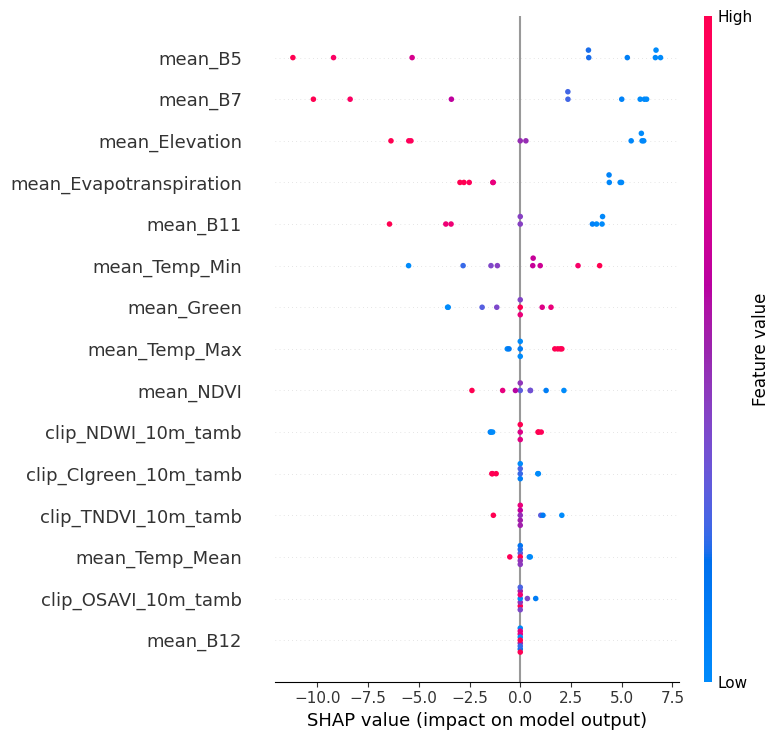


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [23]:
explainer = shap.KernelExplainer(best_model.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## Decision tree regression

In [24]:
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dtr', DecisionTreeRegressor(random_state=42))
])

# --- Hiperparámetros para evitar sobreajuste ---
# Limitamos la profundidad y exigimos más muestras para dividir o crear una hoja.
param_grid_dt = {
    'dtr__max_depth': [3, 4, 5, 6],
    'dtr__min_samples_split': [5, 10],
    'dtr__min_samples_leaf': [3, 4, 5]
}

# --- Búsqueda con LOOCV ---
loocv = LeaveOneOut()
grid_search_dt = GridSearchCV(estimator=pipe_dt,
                              param_grid=param_grid_dt,
                              cv=loocv,
                              scoring='neg_mean_squared_error',
                              n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

# --- Resultados ---
print("--- Árbol de Decisión ---")
print(f"Mejores Hiperparámetros: {grid_search_dt.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_dt.best_score_:.4f}")

--- Árbol de Decisión ---
Mejores Hiperparámetros: {'dtr__max_depth': 3, 'dtr__min_samples_leaf': 5, 'dtr__min_samples_split': 5}
Mejor MSE en CV: 7266.3824


In [25]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_dt = grid_search_dt.best_estimator_
predictions_train_dt= best_model_dt.predict(X_train)
predictions_test_dt = best_model_dt.predict(X_test)

In [26]:
metricas(y_train,predictions_train_dt,y_test,predictions_test_dt)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 38.5177
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 51.9730
R² (Coeficiente de Determinación) de Entrenamiento: 0.5914
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 34.96%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 54.3312
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 83.8683
R² (Coeficiente de Determinación) de Prueba: 0.3563
MAPE (Error Porcentual Absoluto Medio) de Prueba: 36.91%




(38.517678883601626,
 np.float64(51.97301324081908),
 0.5914459229156273,
 np.float64(34.96179591887558),
 54.331161662523115,
 np.float64(83.8683223983941),
 0.3562655510143251,
 np.float64(36.91407044854745))

  0%|          | 0/9 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


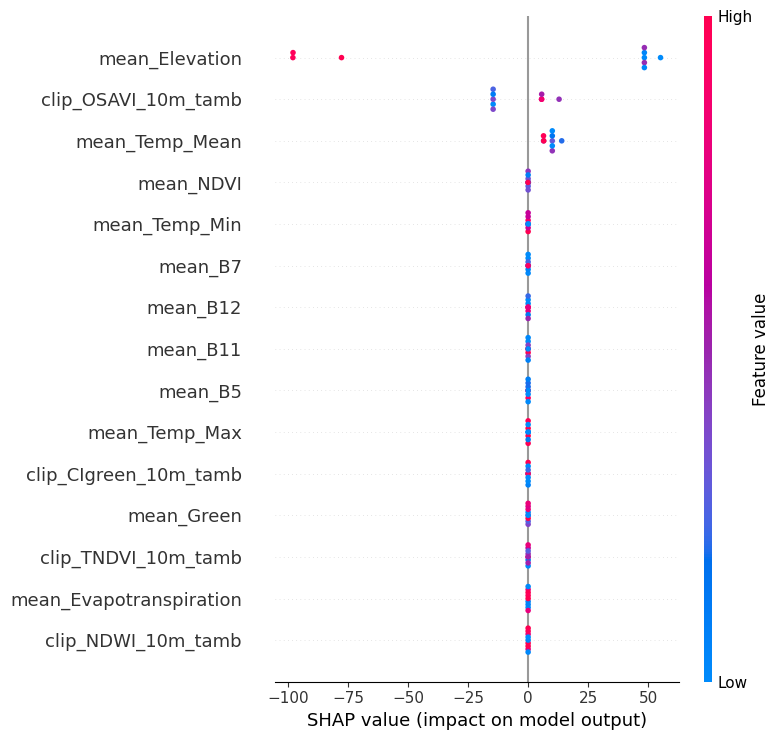


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [27]:
explainer = shap.KernelExplainer(best_model_dt.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## Random Forest



In [28]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42))
])

# --- Hiperparámetros para evitar sobreajuste ---
# Controlamos la profundidad de los árboles y el número de ellos.
param_grid_rf = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [3, 4, 5],
    'rf__min_samples_leaf': [3, 5],
    'rf__max_features': ['sqrt', 0.7]
}

# --- Búsqueda con LOOCV ---
grid_search_rf = GridSearchCV(estimator=pipe_rf, param_grid=param_grid_rf, cv=loocv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# --- Resultados ---
print("\n--- Random Forest ---")
print(f"Mejores Hiperparámetros: {grid_search_rf.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_rf.best_score_:.4f}")


--- Random Forest ---
Mejores Hiperparámetros: {'rf__max_depth': 3, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100}
Mejor MSE en CV: 4692.7200


In [29]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_rf = grid_search_rf.best_estimator_
predictions_train_rf= best_model_rf.predict(X_train)
predictions_test_rf = best_model_rf.predict(X_test)

In [30]:
metricas(y_train,predictions_train_rf,y_test,predictions_test_rf)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 40.6413
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 54.4810
R² (Coeficiente de Determinación) de Entrenamiento: 0.5511
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 41.58%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 55.3321
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 82.7808
R² (Coeficiente de Determinación) de Prueba: 0.3729
MAPE (Error Porcentual Absoluto Medio) de Prueba: 45.42%




(40.641316876069034,
 np.float64(54.481044927571304),
 0.5510638139269979,
 np.float64(41.57569799474255),
 55.33205083046905,
 np.float64(82.78078977353172),
 0.3728521038780307,
 np.float64(45.42491355462809))

  0%|          | 0/9 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


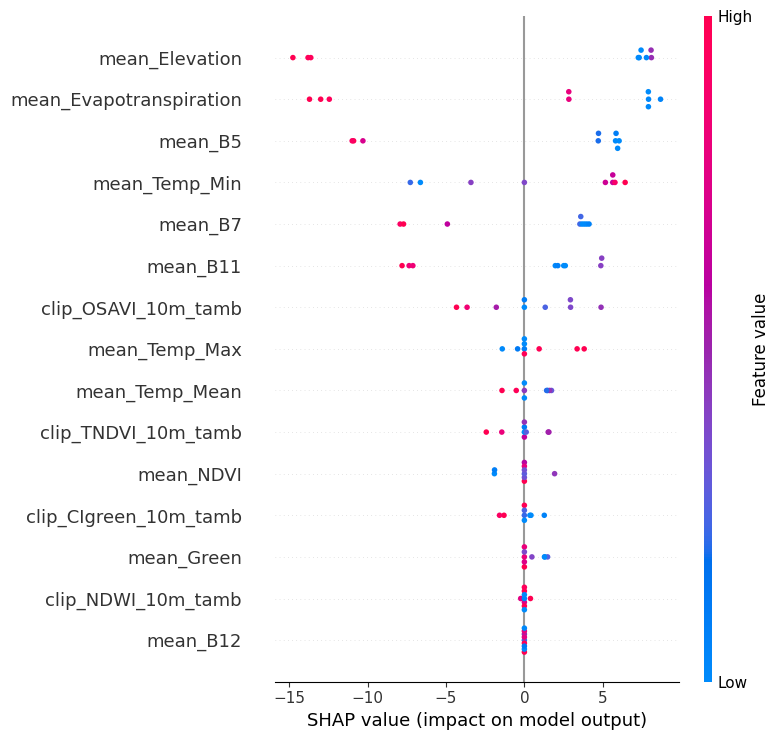


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [31]:
explainer = shap.KernelExplainer(best_model_rf.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## LASSO

In [32]:
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000)) # Aumentamos iteraciones para evitar warnings de convergencia
])

# --- Hiperparámetros para evitar sobreajuste ---
# 'alpha' es la fuerza de la regularización. Un valor más alto significa un modelo más simple.
param_grid_lasso = {
    'lasso__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
}

# --- Búsqueda con LOOCV ---
grid_search_lasso = GridSearchCV(estimator=pipe_lasso, param_grid=param_grid_lasso, cv=loocv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_train, y_train)

# --- Resultados ---
print("\n--- Lasso ---")
print(f"Mejores Hiperparámetros: {grid_search_lasso.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_lasso.best_score_:.4f}")


--- Lasso ---
Mejores Hiperparámetros: {'lasso__alpha': 10.0}
Mejor MSE en CV: 4759.2679


In [33]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_lasso = grid_search_lasso.best_estimator_
predictions_train_lasso= best_model_lasso.predict(X_train)
predictions_test_lasso = best_model_lasso.predict(X_test)

In [34]:
metricas(y_train,predictions_train_lasso,y_test,predictions_test_lasso)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 46.9922
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 61.6285
R² (Coeficiente de Determinación) de Entrenamiento: 0.4255
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 49.87%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 56.0269
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 87.8343
R² (Coeficiente de Determinación) de Prueba: 0.2939
MAPE (Error Porcentual Absoluto Medio) de Prueba: 50.65%




(46.99221167305343,
 np.float64(61.62845729064418),
 0.42554455754140486,
 np.float64(49.87049940919403),
 56.026923830662696,
 np.float64(87.83432294821878),
 0.2939436639526922,
 np.float64(50.65289282391643))

  0%|          | 0/9 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


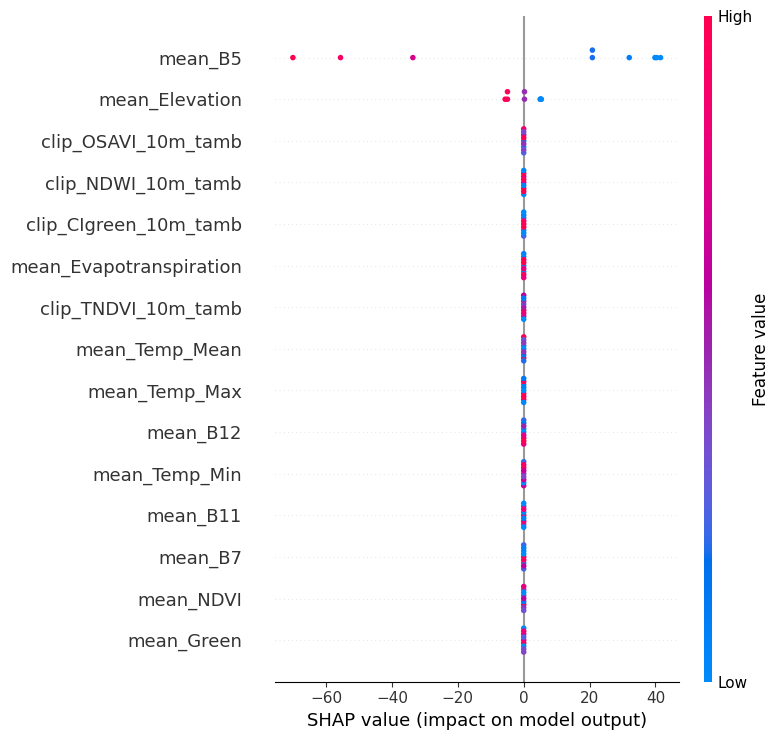


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [35]:
explainer = shap.KernelExplainer(best_model_lasso.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## Ride

In [36]:
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# --- Hiperparámetros para evitar sobreajuste ---
param_grid_ridge = {
    'ridge__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]
}

# --- Búsqueda con LOOCV ---
grid_search_ridge = GridSearchCV(estimator=pipe_ridge, param_grid=param_grid_ridge, cv=loocv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_ridge.fit(X_train, y_train)

# --- Resultados ---
print("\n--- Ridge ---")
print(f"Mejores Hiperparámetros: {grid_search_ridge.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_ridge.best_score_:.4f}")


--- Ridge ---
Mejores Hiperparámetros: {'ridge__alpha': 100.0}
Mejor MSE en CV: 5133.3719


In [37]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_ridge = grid_search_ridge.best_estimator_
predictions_train_ridge= best_model_ridge.predict(X_train)
predictions_test_ridge = best_model_ridge.predict(X_test)

In [38]:
metricas(y_train,predictions_train_ridge,y_test,predictions_test_ridge)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 49.6615
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 64.7463
R² (Coeficiente de Determinación) de Entrenamiento: 0.3660
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 57.35%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 59.3587
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 91.9216
R² (Coeficiente de Determinación) de Prueba: 0.2267
MAPE (Error Porcentual Absoluto Medio) de Prueba: 59.66%




(49.66151001028005,
 np.float64(64.74628425280879),
 0.3659500762153238,
 np.float64(57.3545151413375),
 59.35872514265093,
 np.float64(91.92163022323791),
 0.22670309039701053,
 np.float64(59.657400866551015))

  0%|          | 0/9 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


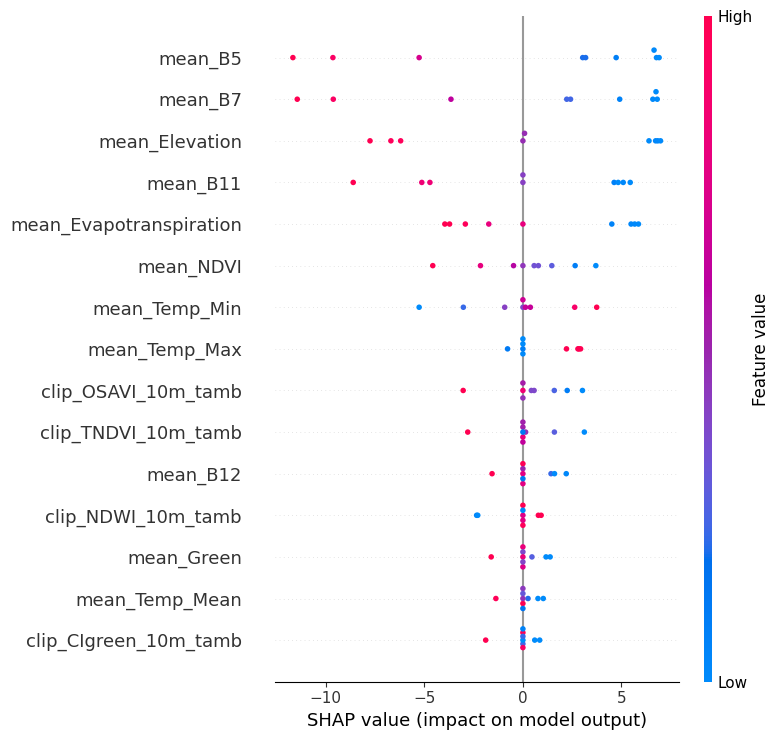


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [39]:
explainer = shap.KernelExplainer(best_model_ridge.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_1)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test_1, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## XGboost


In [40]:
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

# --- Hiperparámetros para evitar sobreajuste ---
# Combinamos una tasa de aprendizaje baja con pocos estimadores, árboles poco profundos y regularización.
param_grid_xgb = {
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth': [2, 3, 4],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__subsample': [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8]
}

# --- Búsqueda con LOOCV ---
grid_search_xgb = GridSearchCV(estimator=pipe_xgb, param_grid=param_grid_xgb, cv=loocv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

# --- Resultados ---
print("\n--- XGBoost ---")
print(f"Mejores Hiperparámetros: {grid_search_xgb.best_params_}")
print(f"Mejor MSE en CV: {-grid_search_xgb.best_score_:.4f}")


--- XGBoost ---
Mejores Hiperparámetros: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 2, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Mejor MSE en CV: 5280.2335


In [41]:
# {'Best Params': {'C': 0.1, 'gamma': 'scale'}
best_model_xgb = grid_search_xgb.best_estimator_
predictions_train_xgb= best_model_xgb.predict(X_train)
predictions_test_xgb = best_model_xgb.predict(X_test)

In [42]:
metricas(y_train,predictions_train_xgb,y_test,predictions_test_xgb)

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 42.8573
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 57.1192
R² (Coeficiente de Determinación) de Entrenamiento: 0.5065
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 50.82%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 63.3903
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 92.8772
R² (Coeficiente de Determinación) de Prueba: 0.2105
MAPE (Error Porcentual Absoluto Medio) de Prueba: 59.83%




(42.85733198840427,
 np.float64(57.11917236798641),
 0.506533622000489,
 np.float64(50.81971351784003),
 63.390342202877264,
 np.float64(92.87716496878983),
 0.21054252846637522,
 np.float64(59.828965103529555))

In [43]:
X_test

array([[ 0.38960806, -0.47308896, -0.99443459, -1.0518744 , -0.89518258,
        -0.867318  ,  0.14291587,  1.41003009, -0.50056174, -1.24260113,
        -1.59517718, -0.68544175,  0.73204517, -0.7424647 , -0.78304592],
       [-1.56842943, -0.35148242, -0.5204616 , -0.41939021, -0.04189298,
         0.6218457 ,  0.10601605, -0.76886452, -0.75751345, -0.05550915,
         0.44836249, -0.8269432 ,  0.81419822, -0.42194658, -0.19507522],
       [-1.56842943, -0.35148242, -0.5204616 , -0.41939021, -0.04189298,
         0.6218457 ,  0.10601605, -0.76886452, -0.75751345, -0.05550915,
         0.44836249, -0.8269432 ,  0.81419822, -0.42194658, -0.19507522],
       [ 0.57414915, -1.30199329, -1.0085386 , -1.06704707, -1.0064235 ,
        -1.11865287,  0.45176607,  1.42277077, -0.21762673, -1.20927635,
        -1.54818551, -0.82218   ,  0.82765784, -1.52519397, -1.66445771],
       [-0.52395516, -0.93919029, -1.03685662, -1.07799287, -1.05645777,
        -1.41745448,  0.70078429,  1.43778292, 

  0%|          | 0/9 [00:00<?, ?it/s]

Cálculo de SHAP completado.

Mostrando el Gráfico de Resumen (Summary Plot)...


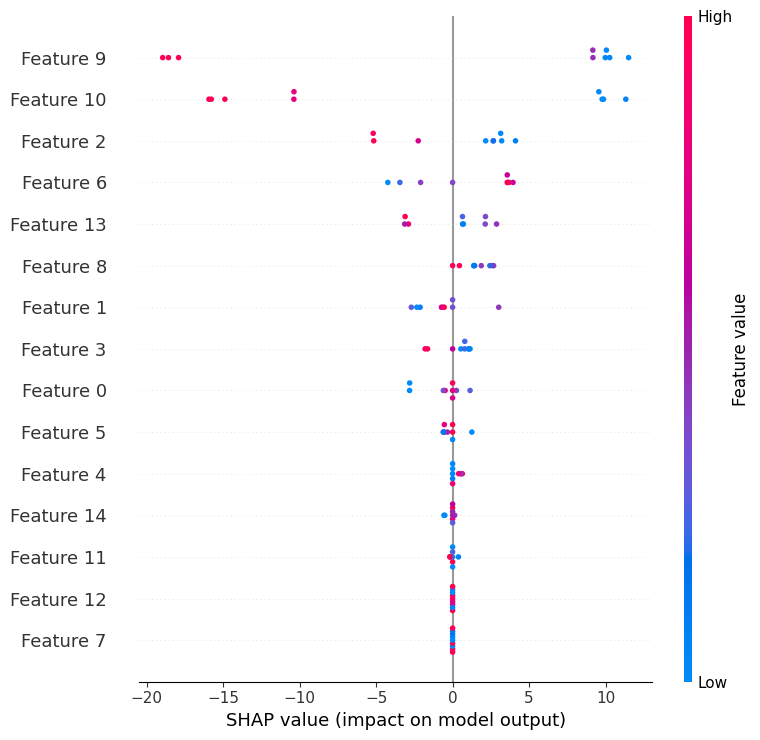


Mostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...


In [44]:
explainer = shap.KernelExplainer(best_model_xgb.predict, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test)

print("Cálculo de SHAP completado.")


# 4. VISUALIZACIÓN E INTERPRETACIÓN 📊

# Gráfico de Resumen (Summary Plot) - El más importante
print("\nMostrando el Gráfico de Resumen (Summary Plot)...")
shap.summary_plot(shap_values, X_test, plot_type="dot")

# Gráfico de Fuerza (Force Plot) para una predicción individual
# Explica por qué el modelo hizo una predicción específica para la primera muestra del test.
print("\nMostrando el Gráfico de Fuerza (Force Plot) para la primera predicción...")
shap.initjs() # Necesario para mostrar los gráficos en notebooks
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test[0,:])

## Resultados

In [45]:
column_names = [
    'MAE_Train', 'RMSE_Train', 'R2_Train', 'MAPE_Train',
    'MAE_Test', 'RMSE_Test', 'R2_Test', 'MAPE_Test'
]

# 2. Define los nombres de tus modelos (las filas)
model_names = [
    'SVM',
    'Descision Tree',
    'Random Forest',
    'Lasso',
    'Ride',
    'XGBoost'
]

# 3. Recolecta los resultados de cada modelo en una lista de tuplas
#    (He simulado los resultados de otros modelos para el ejemplo)
model_results = [
   metricas(y_train,predictions_train_svm,y_test,predictions_test_svm),
   metricas(y_train,predictions_train_dt,y_test,predictions_test_dt),
   metricas(y_train,predictions_train_rf,y_test,predictions_test_rf),
   metricas(y_train,predictions_train_lasso,y_test,predictions_test_lasso),
   metricas(y_train,predictions_train_ridge,y_test,predictions_test_ridge),
   metricas(y_train,predictions_train_xgb,y_test,predictions_test_xgb)
]

# 4. Crea el DataFrame 📊
df_resultados = pd.DataFrame(data=model_results, index=model_names, columns=column_names)

# Opcional: Redondear los valores para una mejor visualización
df_resultados = df_resultados.round(4)
df_resultados

--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 45.5706
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 68.6301
R² (Coeficiente de Determinación) de Entrenamiento: 0.2876
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 46.37%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 61.4119
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 96.9094
R² (Coeficiente de Determinación) de Prueba: 0.1405
MAPE (Error Porcentual Absoluto Medio) de Prueba: 51.68%


--- Métricas en el Conjunto de Entrenamiento ---
MAE (Error Absoluto Medio) de Entrenamiento: 38.5177
RMSE (Raíz del Error Cuadrático Medio) de Entrenamiento: 51.9730
R² (Coeficiente de Determinación) de Entrenamiento: 0.5914
MAPE (Error Porcentual Absoluto Medio) de Entrenamiento: 34.96%


--- Métricas en el Conjunto de Prueba ---
MAE (Error Absoluto Medio) de Prueba: 54.3312
RMSE (Raíz del Error Cuadrático Medio) de Prueba: 83.8683
R² (Coeficien

,MAE_Train,RMSE_Train,R2_Train,MAPE_Train,MAE_Test,RMSE_Test,R2_Test,MAPE_Test
SVM,45.5706,68.6301,0.2876,46.3708,61.4119,96.9094,0.1405,51.6752
Descision Tree,38.5177,51.9730,0.5914,34.9618,54.3312,83.8683,0.3563,36.9141
Random Forest,40.6413,54.4810,0.5511,41.5757,55.3321,82.7808,0.3729,45.4249
Lasso,46.9922,61.6285,0.4255,49.8705,56.0269,87.8343,0.2939,50.6529
Ride,49.6615,64.7463,0.3660,57.3545,59.3587,91.9216,0.2267,59.6574
XGBoost,42.8573,57.1192,0.5065,50.8197,63.3903,92.8772,0.2105,59.8290


In [46]:
df_resultados

,MAE_Train,RMSE_Train,R2_Train,MAPE_Train,MAE_Test,RMSE_Test,R2_Test,MAPE_Test
SVM,45.5706,68.6301,0.2876,46.3708,61.4119,96.9094,0.1405,51.6752
Descision Tree,38.5177,51.9730,0.5914,34.9618,54.3312,83.8683,0.3563,36.9141
Random Forest,40.6413,54.4810,0.5511,41.5757,55.3321,82.7808,0.3729,45.4249
Lasso,46.9922,61.6285,0.4255,49.8705,56.0269,87.8343,0.2939,50.6529
Ride,49.6615,64.7463,0.3660,57.3545,59.3587,91.9216,0.2267,59.6574
XGBoost,42.8573,57.1192,0.5065,50.8197,63.3903,92.8772,0.2105,59.8290


In [47]:
variables = ['mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration',
       'clip_CIgreen_10m_tamb', 'clip_NDWI_10m_tamb', 'clip_OSAVI_10m_tamb',
       'clip_TNDVI_10m_tamb']

In [48]:
# ================================================================
# 6️⃣ APLICAR MODELO A RASTER MULTIBANDA
# ================================================================
ruta_tif = ruta_final

with rasterio.open(ruta_tif) as src:
    img = src.read()  # (bandas, filas, columnas)
    profile = src.profile # Guarda el perfil para exportar después

print(f"\nBandas encontradas en el raster: {img.shape[0]}")

if img.shape[0] < len(variables):
    raise ValueError("El raster no contiene todas las bandas esperadas.")

# 1. PREPARAR DATOS
# ----------------------------------------------------------------
# Reorganizar a (píxeles, bandas)
n_bands, n_rows, n_cols = img.shape
pixels = img.reshape(n_bands, -1).T
X_raster = pd.DataFrame(pixels, columns=variables)

# Reemplazar infinitos por NaN
X_raster.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. SEPARAR PÍXELES VÁLIDOS Y NULOS
# ----------------------------------------------------------------
# Crear una máscara booleana: True para filas sin ningún NaN
valid_pixels_mask = ~X_raster.isnull().any(axis=1)

# Crear el DataFrame solo con los datos válidos que se procesarán
X_raster_valid = X_raster[valid_pixels_mask]


# 3. APLICAR MODELO (SOLO A DATOS VÁLIDOS)
# ----------------------------------------------------------------
# Crear un array para el resultado final, inicializado con NaN
# Usamos np.nan en lugar de -999999 como valor nulo estándar
final_prediction = np.full(X_raster.shape[0], np.nan)

# Proceder solo si hay píxeles válidos que procesar
if not X_raster_valid.empty:
    # Estandarizar únicamente los datos válidos
    X_raster_valid_scaled = scaler.transform(X_raster_valid)

    # Predecir sobre los datos estandarizados
    predictions = best_model_ridge.predict(X_raster_valid_scaled)

    # Insertar las predicciones en las posiciones correctas del array final
    final_prediction[valid_pixels_mask] = predictions


# 4. RECONSTRUIR EL RASTER DE SALIDA
# ----------------------------------------------------------------
# Reconvertir el vector de predicciones a su forma matricial (filas, columnas)
prediction_reshaped = final_prediction.reshape(n_rows, n_cols)

print("\nProceso completado.")
print(f"Forma del resultado: {prediction_reshaped.shape}")
print(f"Total de píxeles: {n_rows * n_cols}")
print(f"Píxeles procesados: {len(X_raster_valid)}")
print(f"Píxeles con NaN (ignorados): {np.isnan(prediction_reshaped).sum()}")


Bandas encontradas en el raster: 15

Proceso completado.
Forma del resultado: (330, 302)
Total de píxeles: 99660
Píxeles procesados: 48046
Píxeles con NaN (ignorados): 51614


In [50]:
with rasterio.open(ruta_tif) as src:
    meta = src.meta
    height, width = src.height, src.width
    # ...

# ... (Aquí ocurre toda la predicción del modelo) ...

# 2. ACTUALIZA DETALLES MENORES EN LA ETIQUETA
# Cambiamos el tipo de dato a float (para las probabilidades) y el número de bandas a 1.
# ¡No tocamos el CRS ni la transformación!
meta.update(dtype='float32', count=1)

# 3. CREA EL ARCHIVO DE SALIDA USANDO LA ETIQUETA ORIGINAL
# La magia ocurre en '**meta'
# Esto le pasa toda la información geográfica guardada a tu nuevo archivo.
output_path = "/content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS/mapa_DRY_WEIGHT_1.tif"
with rasterio.open(output_path, 'w', **meta) as dst:
    dst.write(prediction_reshaped, 1)

In [ ]:
prediction_reshaped_1 = np.where(prediction_reshaped < 0, np.nan, prediction_reshaped)

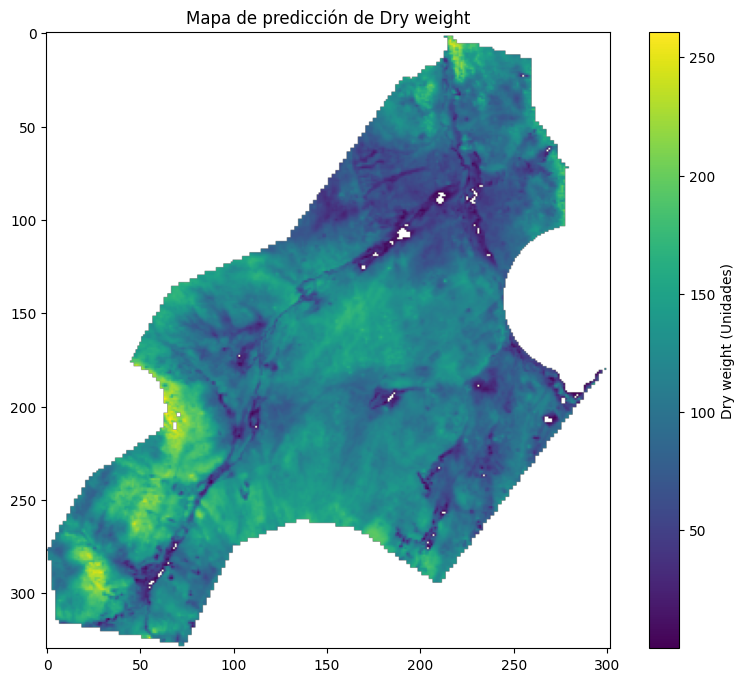

In [ ]:
plt.figure(figsize=(10, 8)) # Ajusta el tamaño para una mejor proporción
plt.imshow(prediction_reshaped_1, cmap='viridis')
plt.colorbar(label='Dry weight (Unidades)')
plt.title('Mapa de predicción de Dry weight')

# Guardar la figura con alta resolución (300 DPI)
plt.savefig('Mapa_Dry_weight_resolucion.tif', dpi=300, bbox_inches='tight')
plt.show() # Puedes seguir mostrándolo si quieres

In [ ]:

# 1. Abre el archivo de origen para leer sus metadatos
try:
    with rasterio.open('/content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS/Mapa_Dry_weight_resolucion.tif') as src:
        # Copia el perfil (metadatos) del archivo de origen
        profile = src.profile

        # Obtén la transformación y el CRS originales
        transform = src.transform
        crs_original = src.crs

    # 2. Actualiza el perfil para tu nuevo archivo de salida
    # Asegúrate de que el tipo de dato (dtype) coincida con tu array de predicción
    profile.update(
        dtype=prediction_reshaped.dtype,
        count=1,  # Número de bandas (asumimos 1 para tu mapa de carbono)
        compress='lzw' # Opcional: añade compresión
    )

    # 3. Asigna el CRS deseado (EPSG:32719)
    # ¡Importante! Esto solo RE-ETIQUETA el archivo.
    # NO lo reproyecta. Si el archivo de origen NO está en 32719,
    # necesitarías reproyectarlo, lo cual es un paso más complejo.
    # Por ahora, asumimos que quieres ETIQUETARLO como 32719.
    profile['crs'] = CRS.from_epsg(32719)

    # 4. Escribe tu array 'prediction_reshaped' en un nuevo archivo GeoTIFF
    with rasterio.open('Dry_weight_georreferenciado.tif', 'w', **profile) as dst:
        dst.write(prediction_reshaped, 1) # Escribe en la banda 1

    print("¡GeoTIFF guardado exitosamente!")

except FileNotFoundError:
    print("Error: No se encontró el archivo 'imagen_origen.tif'.")
    print("Necesitas un archivo de origen para copiar la georreferenciación.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


¡GeoTIFF guardado exitosamente!
